# 🤗 Hugging Face Transformers — Pretrained Models, Tokenizers, and Fine-Tuning

> **What you'll learn:** how to find, judge, and pin pretrained models on the Hugging Face Hub; how tokenizers really turn text into numbers (WordPiece, BPE, Unigram, padding, token-based truncation, attention masks, offsets); which transformer family fits which task; how to fine-tune a sentiment classifier and a named-entity tagger with `Trainer`; how to chat with a small local LLM; how LoRA trains ~1% of the weights; and how to make inference fast — all on a laptop, with real datasets.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Embeddings and Semantic Search](02_Embeddings_and_Semantic_Search.ipynb) (vectors, pooling, cosine similarity) · [Transformers From Scratch](../04_Deep_Learning/03_Transformers_From_Scratch.ipynb) (attention, masks, GPT) · [PyTorch](../04_Deep_Learning/02_PyTorch.ipynb) (tensors, training loops) |
| **Tested with** | Python 3.12 · transformers 5.17 · datasets 5.0 · evaluate 0.4 · peft 0.20 · accelerate 1.15 · torch 2.14 (Apple MPS, CUDA, or CPU) |
| **Interview relevance** | ⭐⭐⭐ Very high — "compare WordPiece, BPE and SentencePiece", "what does the attention mask do?", "fine-tune, extract features, or prompt?", "how does LoRA work?", "how do you handle documents longer than 512 tokens?", "validation looks great but production is bad — why?" |

## 🤔 What Is Hugging Face Transformers?

Training a language model from zero costs a fortune in data and compute. **Pretrained models** let you skip that: someone already taught a model general language skills on huge amounts of text, and you **reuse** it — as is, or after a short extra training run on your own data (**fine-tuning**).

**Hugging Face** is the company and open-source community that made this reuse easy. Think of it as an **app store plus a universal charger**: the store hosts the models, and one standard plug fits them all.

| Piece | What it is | Everyday analogy |
|---|---|---|
| **Hub** (huggingface.co) | over a million public model repositories, plus datasets and demo apps; each repo is a git repository with a README called a **model card** | the app store |
| **`transformers`** | one Python API to load, run, and train those models (`from_pretrained`, `pipeline`, `Trainer`) | the universal charger |
| **`tokenizers`** | fast (Rust) tokenizers that turn text into integer IDs | a translator between words and numbers |
| **`datasets`** | download, slice, and preprocess datasets without loading everything into RAM | a library card for data |
| **`evaluate`** | standard metrics such as accuracy, F1, and `seqeval` | the marking scheme |
| **`peft`** | parameter-efficient fine-tuning, e.g. **LoRA** | sticky notes on a textbook instead of rewriting it |
| **`accelerate`** | runs the same training code on CPU, Apple MPS, or one or many GPUs | an automatic gearbox |

Every model call follows the same path:

```
"I loved it!" ──► tokenizer ──► input_ids [101, 1045, 3866, 2009, 999, 102]  +  attention_mask [1, 1, 1, 1, 1, 1]
                                       │
                                       ▼
                     model body (stack of transformer layers) ──► hidden states  (batch, tokens, 768)
                                       │
                                       ▼
                     task head (a small Linear layer) ──► logits [negative, positive] ──► softmax ──► "POSITIVE 0.99…"
```

> **Version note:** since **transformers v5** the library is **PyTorch-only** — the old TensorFlow and JAX/Flax model classes were removed. Everything here is PyTorch.

## 🎯 Why It Matters

- **It is the default toolbox for applied NLP and LLM work.** Fine-tuning a classifier or entity tagger, running a small open model locally, and training LoRA adapters all start with `from_pretrained`.
- **Pretrained + fine-tuned beats from-scratch** for almost every text task with limited labels: a few thousand examples and a few minutes of training give strong accuracy (you will measure it below).
- **Engineering decisions live here:** which model (license, size, latency), how many tokens a request costs, what happens to text longer than the model's limit, how to evaluate without leakage, and which precision to serve in.
- **In interviews** for AI/ML engineer roles you are expected to explain tokenization and attention masks, choose between encoder and decoder models, justify fine-tuning vs prompting, describe LoRA's rank and alpha, handle long documents, and debug label-mapping or padding bugs. Each of those is practised in this notebook.

## ✅ By the End You Can

- [ ] Choose a Hub model by task, license, size, and model card — and pin its exact revision
- [ ] Explain and use tokenizers: WordPiece vs BPE vs Unigram, special tokens, padding, truncation by tokens, attention masks, offsets, and sliding windows
- [ ] Pick the right architecture family (encoder, decoder, encoder–decoder) and `Auto` class for a task
- [ ] Fine-tune and evaluate a text classifier and a NER model with `datasets`, `Trainer`, and `evaluate` — with early stopping and no test-set leakage
- [ ] Generate text with a chat model using chat templates, sampling parameters, and stopping rules
- [ ] Apply LoRA with `peft`, measure inference speed-ups, and rebuild WordPiece and the `Trainer` loop from scratch

## 📋 Table of Contents

1. [The Hugging Face Ecosystem: Hub, Model Cards, Licenses, Revisions](#1.-The-Hugging-Face-Ecosystem:-Hub,-Model-Cards,-Licenses,-Revisions-🟢)
2. [The pipeline() Function — Quick Wins and Limits](#2.-The-pipeline()-Function-—-Quick-Wins-and-Limits-🟢)
3. [Tokenizers I: Subwords with WordPiece, BPE, and Unigram](#3.-Tokenizers-I:-Subwords-with-WordPiece,-BPE,-and-Unigram-🟢)
4. [Tokenizers II: Padding, Truncation, Attention Masks, Offsets](#4.-Tokenizers-II:-Padding,-Truncation,-Attention-Masks,-Offsets-🟡)
5. [Auto Classes, Hidden States, and Task Heads](#5.-Auto-Classes,-Hidden-States,-and-Task-Heads-🟢)
6. [Three Architecture Families: Encoder, Decoder, Encoder–Decoder](#6.-Three-Architecture-Families:-Encoder,-Decoder,-Encoder–Decoder-🟡)
7. [The datasets Library](#7.-The-datasets-Library-🟢)
8. [Fine-Tuning a Text Classifier with Trainer](#8.-Fine-Tuning-a-Text-Classifier-with-Trainer-🟡)
9. [Token Classification (NER) and Label Alignment](#9.-Token-Classification-(NER)-and-Label-Alignment-🔴)
10. [Text Generation with a Small Instruct Model](#10.-Text-Generation-with-a-Small-Instruct-Model-🟡)
11. [LoRA with peft — A First Look](#11.-LoRA-with-peft-—-A-First-Look-🔴)
12. [Inference Efficiency: Batching, inference_mode, and dtypes](#12.-Inference-Efficiency:-Batching,-inference_mode,-and-dtypes-🟡)
13. [Saving and Loading: the save_pretrained Round Trip](#13.-Saving-and-Loading:-the-save_pretrained-Round-Trip-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Full-Fine-Tuning-vs-LoRA-Sentiment-Classifier) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

**What gets downloaded (once, then cached in `~/.cache/huggingface`)** — about 0.8 GB in total:

| Repo | Size | Used for |
|---|---|---|
| `distilbert/distilbert-base-uncased` | ~270 MB | the encoder we fine-tune (classification, NER, LoRA) |
| `distilbert/distilbert-base-uncased-finetuned-sst-2-english` | ~270 MB | a ready-made sentiment model for `pipeline()` and as a reference |
| `HuggingFaceTB/SmolLM2-135M-Instruct` | ~270 MB | a small chat model for text generation |
| `sentence-transformers/all-MiniLM-L6-v2` | ~90 MB | a trained sentence-embedding model (one pitfall) |
| GPT-2 and T5 **tokenizers only**, SST-2 and CoNLL-2003 datasets | a few MB | tokenizer comparison, training data |

**Quiet logs.** The cell turns off download progress bars and library warnings so the saved outputs stay readable. Two messages you would otherwise see: a Hub notice suggesting you set an `HF_TOKEN` (optional; it only raises download rate limits) and a "LOAD REPORT" listing newly created weights — Section 5 shows that information explicitly instead. While debugging your own code, turn logs back on with `transformers.logging.set_verbosity_warning()`.

**Hardware.** The code picks CUDA, then Apple **MPS**, then CPU. The whole notebook takes a few minutes on an Apple-silicon laptop; on a CPU-only machine the training cells are several times slower.

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "transformers>=5.0" "datasets>=4.0" "evaluate>=0.4" "peft>=0.17" "accelerate>=1.0" seqeval "torch>=2.4" pandas matplotlib scikit-learn

import os

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")      # avoids a fork warning from the Rust tokenizers
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")    # keep download bars out of the saved outputs

import gc
import json
import re
import shutil
import sys
import time
from pathlib import Path

import accelerate
import datasets
import evaluate
import huggingface_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import peft
import torch
import transformers

transformers.logging.set_verbosity_error()
datasets.disable_progress_bars()
evaluate.logging.disable_progress_bar()
evaluate.logging.set_verbosity_error()
huggingface_hub.utils.logging.set_verbosity_error()

print(f"Python {sys.version.split()[0]} | torch {torch.__version__} | transformers {transformers.__version__} | "
      f"datasets {datasets.__version__} | evaluate {evaluate.__version__} | peft {peft.__version__} | accelerate {accelerate.__version__}")
print("TensorFlow model classes present in transformers:", hasattr(transformers, "TFAutoModel"), "(v5 is PyTorch-only)")

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", DEVICE)

SEED = 42
transformers.set_seed(SEED)                     # seeds Python, NumPy, and torch in one call
pd.set_option("display.max_colwidth", 120)
OUTPUT_DIR = Path("_outputs") / "hf_transformers"   # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ENCODER = "distilbert/distilbert-base-uncased"
SENTIMENT_MODEL = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
CHAT_MODEL = "HuggingFaceTB/SmolLM2-135M-Instruct"


def free_memory():
    """Release cached accelerator memory after `del`-ing a model (important with limited RAM)."""
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def check(name, got, expected, hint="", atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return

    def close(a, b):
        if isinstance(b, (str, bool)) or b is None:
            return a == b
        if isinstance(b, dict):
            return isinstance(a, dict) and set(a) == set(b) and all(close(a[k], b[k]) for k in b)
        if isinstance(b, (list, tuple)) and isinstance(a, (list, tuple)) and any(isinstance(x, (list, tuple, dict, str)) for x in b):
            return len(a) == len(b) and all(close(x, y) for x, y in zip(a, b))
        try:                                   # numbers, arrays, tensors (also a tensor vs nested lists)
            a_arr, b_arr = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
        except (TypeError, ValueError):
            return a == b
        return a_arr.shape == b_arr.shape and bool(np.allclose(a_arr, b_arr, atol=atol, rtol=0))

    assert close(got, expected), f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | torch 2.14.0 | transformers 5.17.0 | datasets 5.0.1 | evaluate 0.4.6 | peft 0.20.0 | accelerate 1.15.0
TensorFlow model classes present in transformers: False (v5 is PyTorch-only)
device: mps


## 1. The Hugging Face Ecosystem: Hub, Model Cards, Licenses, Revisions 🟢

A **Hub repository** is a git repo holding weights (`model.safetensors`), a `config.json` (the architecture), tokenizer files, and a `README.md` **model card**. Before you use a model, check four things:

1. **Task** — what was it trained to do? (`pipeline_tag`, e.g. `fill-mask`, `text-classification`, `text-generation`)
2. **License** — can your company use it? `apache-2.0` and `mit` allow commercial use; some licenses forbid it (e.g. `cc-by-nc-4.0`) or add conditions (e.g. the Llama community licenses).
3. **Size** — parameters × bytes per parameter ≈ memory. 135M parameters in bfloat16 ≈ 270 MB.
4. **Model card** — training data, intended uses, limitations and bias, evaluation results.

We can read all of this through the Hub API **without downloading any weights**.

In [2]:
from huggingface_hub import HfApi, ModelCard

api = HfApi()
hub_rows = []
for repo_id in [ENCODER, SENTIMENT_MODEL, CHAT_MODEL]:
    info = api.model_info(repo_id, files_metadata=True)            # metadata only
    weight_bytes = sum(f.size or 0 for f in info.siblings
                       if f.rfilename.endswith(".safetensors") and "/" not in f.rfilename)
    hub_rows.append({
        "repo": repo_id,
        "task": info.pipeline_tag,
        "license": info.card_data.get("license") if info.card_data else None,
        "downloads_last_30_days": info.downloads,
        "weights_MB": round(weight_bytes / 1e6),
        "commit": info.sha[:12],
    })
hub_table = pd.DataFrame(hub_rows)
hub_table

,repo,task,license,downloads_last_30_days,weights_MB,commit
0,distilbert/distilbert-base-uncased,fill-mask,apache-2.0,7325282,268,12040accade4
1,distilbert/distilbert-base-uncased-finetuned-sst-2-english,text-classification,apache-2.0,3694452,268,714eb0fa89d2
2,HuggingFaceTB/SmolLM2-135M-Instruct,text-generation,apache-2.0,1380846,269,12fd25f77366


In [3]:
card = ModelCard.load(ENCODER)                   # downloads only the README
print("license in card metadata:", card.data.license)
print("card sections:", [line.lstrip("# ") for line in card.text.splitlines() if line.startswith("## ")])

license in card metadata: apache-2.0
card sections: ['Model description', 'Intended uses & limitations', 'Training data', 'Training procedure', 'Evaluation results']


**Revisions and pinning.** `from_pretrained("owner/name")` fetches whatever the `main` branch holds *today*. If the owner pushes new weights or a changed tokenizer tomorrow, your results silently change. For anything you ship or report, **pin the commit hash** with `revision=`:

In [4]:
from transformers import AutoConfig

encoder_sha = api.model_info(ENCODER).sha                        # the exact commit behind "main" right now
config = AutoConfig.from_pretrained(ENCODER, revision=encoder_sha)
print(f"pinned {ENCODER}@{encoder_sha[:12]}")
print(f"model_type={config.model_type} | layers={config.n_layers} | hidden size={config.dim} | "
      f"vocab={config.vocab_size:,} | max positions={config.max_position_embeddings}")

pinned distilbert/distilbert-base-uncased@12040accade4
model_type=distilbert | layers=6 | hidden size=768 | vocab=30,522 | max positions=512


Other Hub habits worth knowing:

- Prefer **`safetensors`** weights: loading them cannot run code, unlike old pickle-based `pytorch_model.bin` files.
- **`trust_remote_code=True`** runs Python code from the repo on your machine — only use it for repos you trust, and pin the revision.
- **Gated** models (e.g. Llama) require accepting a license on the website and logging in with a token.
- For offline or air-gapped servers, download once, then set `HF_HUB_OFFLINE=1` or pass `local_files_only=True`.

### ✍️ Your Turn

From `hub_table`, get the **license string** of `CHAT_MODEL`.

In [5]:
chat_license = None  # TODO: your code here
check("chat_license", chat_license, "apache-2.0",
      hint="Filter hub_table where the 'repo' column equals CHAT_MODEL, then take the 'license' value with .item().")

⏳ chat_license: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
chat_license = hub_table.loc[hub_table["repo"] == CHAT_MODEL, "license"].item()
check("chat_license", chat_license, "apache-2.0")
```
</details>

> 💡 **Interview angle:** "How do you pick a model from the Hub?" — task fit, **license**, size vs latency/memory budget, the model card's training data and limitations, benchmark results *and* a quick evaluation on your own data, `safetensors` weights, and a **pinned revision** for reproducibility.

## 2. The pipeline() Function — Quick Wins and Limits 🟢

`pipeline(task, model=...)` bundles **tokenizer → model → post-processing** into one callable. It is the fastest way to try a model.

Common tasks: `sentiment-analysis` / `text-classification`, `token-classification` (NER), `question-answering`, `fill-mask`, `text-generation`, `summarization`, `translation`, `zero-shot-classification`, `feature-extraction`. Always pass `model=` explicitly — relying on a task's default model makes your code depend on a choice you did not make.

In [6]:
from transformers import pipeline

sentiment = pipeline("sentiment-analysis", model=SENTIMENT_MODEL, device=DEVICE)
reviews = [
    "An absolute joy from start to finish — I laughed and cried.",
    "The plot made no sense and the acting was wooden.",
    "A solid, well-made thriller with a clever final twist.",
]
for review, pred in zip(reviews, sentiment(reviews, batch_size=8)):
    print(f"{pred['label']:8s} {pred['score']:.4f} | {review}")

POSITIVE 0.9999 | An absolute joy from start to finish — I laughed and cried.
NEGATIVE 0.9998 | The plot made no sense and the acting was wooden.
POSITIVE 0.9999 | A solid, well-made thriller with a clever final twist.


**What the pipeline does under the hood** — the same three steps by hand, which you need as soon as you want batching control, custom post-processing, or a production service:

In [7]:
pipe_tok, pipe_model = sentiment.tokenizer, sentiment.model
batch = pipe_tok(reviews, padding=True, truncation=True, return_tensors="pt").to(pipe_model.device)
with torch.inference_mode():                                     # no gradients needed for inference
    probs = pipe_model(**batch).logits.softmax(dim=-1).cpu()

manual = [(pipe_model.config.id2label[int(i)], float(p)) for i, p in zip(probs.argmax(-1), probs.max(-1).values)]
pipe_scores = [p["score"] for p in sentiment(reviews)]
assert all(abs(score - m[1]) < 1e-3 for score, m in zip(pipe_scores, manual))
print("✅ tokenizer → model → softmax → id2label reproduces the pipeline:", [f"{label} {p:.4f}" for label, p in manual])

✅ tokenizer → model → softmax → id2label reproduces the pipeline: ['POSITIVE 0.9999', 'NEGATIVE 0.9998', 'POSITIVE 0.9999']


**The limits.** A pipeline is only as good as its model. This one was fine-tuned on English movie-review snippets with exactly two classes. Let's probe it with inputs a human reads easily:

In [8]:
tricky = pd.DataFrame({
    "kind": ["neutral", "idiom", "sarcasm", "domain shift (phone review)", "another language"],
    "text": ["It was fine, I guess.",
             "Two hours of my life I will never get back.",
             "Oh great, another two-hour movie that could have been a short email.",
             "The phone battery lasts two hours.",
             "Je n'ai pas aimé ce film."],                       # French: "I did not like this film."
    "human_reading": ["NEUTRAL", "NEGATIVE", "NEGATIVE", "NEGATIVE", "NEGATIVE"],
})
tricky_preds = sentiment(tricky["text"].tolist())
tricky["model_label"] = [p["label"] for p in tricky_preds]
tricky["score"] = [round(p["score"], 4) for p in tricky_preds]
print(tricky.to_string(index=False))

clear = tricky[tricky.human_reading != "NEUTRAL"]
n_wrong = int((clear.model_label != clear.human_reading).sum())
print(f"\nWrong on {n_wrong} of {len(clear)} inputs with a clear reading; "
      f"{int((tricky.score >= 0.9).sum())} of {len(tricky)} predictions still have a score ≥ 0.90.")
print("→ The score is a softmax output, not a calibrated probability, and 'neutral' is not an option for this model.")

                       kind                                                                 text human_reading model_label  score
                    neutral                                                It was fine, I guess.       NEUTRAL    POSITIVE 0.9998
                      idiom                          Two hours of my life I will never get back.      NEGATIVE    POSITIVE 0.7447
                    sarcasm Oh great, another two-hour movie that could have been a short email.      NEGATIVE    NEGATIVE 0.9885
domain shift (phone review)                                   The phone battery lasts two hours.      NEGATIVE    NEGATIVE 0.9829
           another language                                            Je n'ai pas aimé ce film.      NEGATIVE    POSITIVE 0.9345

Wrong on 2 of 4 inputs with a clear reading; 4 of 5 predictions still have a score ≥ 0.90.
→ The score is a softmax output, not a calibrated probability, and 'neutral' is not an option for this model.


Another hard limit: DistilBERT has **512 position embeddings**, so it cannot read longer inputs at all.

In [9]:
long_review = "The first act is slow but the ending is great. " * 120
n_long_tokens = len(pipe_tok(long_review)["input_ids"])
try:
    sentiment(long_review)
    print("no error raised on this device")
except (RuntimeError, IndexError) as err:
    print(f"❌ {n_long_tokens} tokens > limit {pipe_tok.model_max_length}: {type(err).__name__}: {str(err)[:100]}")
print("✅ with truncation=True:", sentiment(long_review, truncation=True), "— but only the first 512 tokens were read (see Pitfall 1)")

❌ 1322 tokens > limit 512: RuntimeError: The size of tensor a (1322) must match the size of tensor b (512) at non-singleton dimension 1
✅ with truncation=True: [{'label': 'POSITIVE', 'score': 0.9956486821174622}] — but only the first 512 tokens were read (see Pitfall 1)


### ✍️ Your Turn

Run `sentiment` on `my_reviews` and store **how many** are predicted `POSITIVE` in `n_positive`.

In [10]:
my_reviews = [
    "The acting was superb and the story moved me.",
    "A dull, lifeless film that wastes a great cast.",
    "I would happily watch it again tomorrow.",
    "The soundtrack alone is worth the ticket.",
    "Tedious, predictable, and far too long.",
    "A warm, funny, and beautifully shot adventure.",
]
n_positive = None  # TODO: your code here
check("n_positive", n_positive, 4, hint="sum(p['label'] == 'POSITIVE' for p in sentiment(my_reviews))")

⏳ n_positive: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
my_reviews = [
    "The acting was superb and the story moved me.",
    "A dull, lifeless film that wastes a great cast.",
    "I would happily watch it again tomorrow.",
    "The soundtrack alone is worth the ticket.",
    "Tedious, predictable, and far too long.",
    "A warm, funny, and beautifully shot adventure.",
]
n_positive = sum(p["label"] == "POSITIVE" for p in sentiment(my_reviews))
check("n_positive", n_positive, 4)
```
</details>

> 💡 **Interview angle:** "When is `pipeline()` not enough?" — when you need your own labels or domain (fine-tune), inputs longer than the model's limit (chunking), calibrated confidence, a "neutral/unknown" option, custom batching for throughput, or tight control over pre- and post-processing in a service.

## 3. Tokenizers I: Subwords with WordPiece, BPE, and Unigram 🟢

Models only read numbers, so a **tokenizer** splits text into **tokens** and maps each to an ID from a fixed **vocabulary**. The unit matters:

| Unit | Vocabulary | Problem |
|---|---|---|
| whole words | huge (every word form) | unseen words become "unknown" |
| characters | tiny | sequences get very long → slow attention |
| **subwords** | 30k–150k pieces | ✅ common words stay whole, rare words split into pieces |

Three subword algorithms dominate:

| Algorithm | Used by | How the vocabulary is learned | How text is split | Marker |
|---|---|---|---|---|
| **WordPiece** | BERT, DistilBERT | merge pairs that most increase training-data likelihood | greedy **longest match first** from the left | `##` = continues the previous piece |
| **BPE** (byte-pair encoding) | GPT-2, Llama 3, Qwen, SmolLM2 | repeatedly merge the **most frequent** adjacent pair | apply learned merges in order; **byte-level** BPE starts from bytes so nothing is ever unknown | `Ġ` = this piece starts with a space |
| **Unigram** | T5, ALBERT, XLNet | start with a big vocabulary, **prune** pieces that matter least | pick the most probable segmentation | `▁` = start of a word |

**SentencePiece** is not a fourth algorithm: it is a library that treats text as a raw character stream (spaces included, shown as `▁`) and trains either **BPE or Unigram** on it — handy for languages without spaces. T5 uses SentencePiece Unigram.

In [11]:
from transformers import AutoTokenizer

tokenizers_by_name = {
    "DistilBERT (WordPiece)": AutoTokenizer.from_pretrained(ENCODER),
    "GPT-2 (byte-level BPE)": AutoTokenizer.from_pretrained("openai-community/gpt2"),
    "SmolLM2 (byte-level BPE)": AutoTokenizer.from_pretrained(CHAT_MODEL),
    "T5 (SentencePiece Unigram)": AutoTokenizer.from_pretrained("google-t5/t5-small"),
}
bert_tok = tokenizers_by_name["DistilBERT (WordPiece)"]
gpt2_tok = tokenizers_by_name["GPT-2 (byte-level BPE)"]
chat_tok = tokenizers_by_name["SmolLM2 (byte-level BPE)"]
t5_tok = tokenizers_by_name["T5 (SentencePiece Unigram)"]

sentence = "Tokenizers split unbelievably rare words like 'ChatGPT' into pieces!"
rows = []
for name, tok in tokenizers_by_name.items():
    pieces = tok.tokenize(sentence)
    rows.append({"tokenizer": name, "algorithm": type(tok.backend_tokenizer.model).__name__, "fast": tok.is_fast,
                 "vocab_size": len(tok), "n_tokens": len(pieces), "tokens": " ".join(pieces)})
pd.DataFrame(rows)

,tokenizer,algorithm,fast,vocab_size,n_tokens,tokens
0,DistilBERT (WordPiece),WordPiece,True,30522,20,token ##izer ##s split un ##bel ##ie ##va ##bly rare words like ' chat ##gp ##t ' into pieces !
1,GPT-2 (byte-level BPE),BPE,True,50257,15,Token izers Ġsplit Ġunbelievably Ġrare Ġwords Ġlike Ġ' Chat G PT ' Ġinto Ġpieces !
2,SmolLM2 (byte-level BPE),BPE,True,49152,16,Token izers Ġsplit Ġunbelie v ably Ġrare Ġwords Ġlike Ġ' Chat GPT ' Ġinto Ġpieces !
3,T5 (SentencePiece Unigram),Unigram,True,32100,22,▁To ken izer s ▁split ▁unbe lie v ably ▁rare ▁words ▁like ▁ ' C hat GP T ' ▁into ▁pieces !


`is_fast=True` means the tokenizer runs in Rust (the `tokenizers` library): it is much faster on batches and gives extras such as **offset mappings** and **`word_ids()`**, used in Sections 4 and 9.

**Normalization and unknown tokens** differ too:

In [12]:
text = "Café naïve 🤗"
print("WordPiece (uncased):", bert_tok.tokenize(text))
print("byte-level BPE     :", gpt2_tok.tokenize(text))
print("GPT-2 decodes back to the exact text:", gpt2_tok.decode(gpt2_tok(text)["input_ids"]) == text)
print("DistilBERT decodes to              :", repr(bert_tok.decode(bert_tok(text, add_special_tokens=False)["input_ids"])))

WordPiece (uncased): ['cafe', 'naive', '[UNK]']
byte-level BPE     : ['C', 'af', 'Ã©', 'ĠnaÃ¯ve', 'ĠðŁ', '¤', 'Ĺ']
GPT-2 decodes back to the exact text: True
DistilBERT decodes to              : 'cafe naive [UNK]'


The uncased WordPiece tokenizer **lowercases and strips accents** and maps characters missing from its vocabulary to `[UNK]` — information is lost. Byte-level BPE keeps every byte, so it can always round-trip the text.

**Special tokens** are added around your text:

In [13]:
pair = bert_tok("I loved it!", "Would watch again.")               # a sentence PAIR (e.g. question + context)
print("tokens   :", pair.tokens())
print("input_ids:", pair["input_ids"])
print("segments :", pair["token_type_ids"], "← token_type_ids: 0 = first text, 1 = second text")
for name, tok in tokenizers_by_name.items():
    print(f"{name:28s} special tokens: {tok.all_special_tokens[:5]}")

tokens   : ['[CLS]', 'i', 'loved', 'it', '!', '[SEP]', 'would', 'watch', 'again', '.', '[SEP]']
input_ids: [101, 1045, 3866, 2009, 999, 102, 2052, 3422, 2153, 1012, 102]
segments : [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1] ← token_type_ids: 0 = first text, 1 = second text
DistilBERT (WordPiece)       special tokens: ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']
GPT-2 (byte-level BPE)       special tokens: ['<|endoftext|>']
SmolLM2 (byte-level BPE)     special tokens: ['<|im_start|>', '<|im_end|>', '<|endoftext|>']
T5 (SentencePiece Unigram)   special tokens: ['</s>', '<unk>', '<pad>', '<extra_id_0>', '<extra_id_1>']


Tokens are also **cost and context**: API prices, context windows, and latency are all counted in tokens. The same meaning can take very different token counts:

In [14]:
samples = {
    "English": "I really enjoyed this film.",
    "Python": "def add(a, b):\n    return a + b",
    "Hindi": "मुझे यह फ़िल्म बहुत पसंद आई।",                         # "I liked this film a lot."
}
for label, s in samples.items():
    counts = {}
    for name, tok in tokenizers_by_name.items():
        pieces = tok.tokenize(s)
        n_unknown = sum(tok.convert_tokens_to_ids(p) == tok.unk_token_id for p in pieces) if tok.unk_token_id is not None else 0
        counts[name.split(" ")[0]] = f"{len(pieces)} ({n_unknown} unknown)"
    print(f"{label:8s} {len(s):3d} characters → tokens {counts}")

English   27 characters → tokens {'DistilBERT': '6 (0 unknown)', 'GPT-2': '6 (0 unknown)', 'SmolLM2': '6 (0 unknown)', 'T5': '6 (0 unknown)'}
Python    31 characters → tokens {'DistilBERT': '12 (0 unknown)', 'GPT-2': '15 (0 unknown)', 'SmolLM2': '12 (0 unknown)', 'T5': '16 (0 unknown)'}
Hindi     28 characters → tokens {'DistilBERT': '12 (3 unknown)', 'GPT-2': '46 (0 unknown)', 'SmolLM2': '35 (0 unknown)', 'T5': '12 (6 unknown)'}


### ✍️ Your Turn

Using `bert_tok`, produce the list of WordPiece **tokens (without special tokens)** for `"Transformers are surprisingly data-efficient."`.

In [15]:
wp_tokens = None  # TODO: your code here
check("wp_tokens", wp_tokens, ["transformers", "are", "surprisingly", "data", "-", "efficient", "."],
      hint="bert_tok.tokenize(...) returns string tokens and skips [CLS]/[SEP].")

⏳ wp_tokens: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
wp_tokens = bert_tok.tokenize("Transformers are surprisingly data-efficient.")
check("wp_tokens", wp_tokens, ["transformers", "are", "surprisingly", "data", "-", "efficient", "."])
```

Punctuation is split off **before** WordPiece runs, which is why `-` and `.` are separate tokens.
</details>

> 💡 **Interview angle:** "Compare WordPiece, BPE, and Unigram." — WordPiece: likelihood-based merges, greedy longest-match, `##`, can emit `[UNK]`. BPE: frequency-based merges; byte-level BPE never needs `[UNK]`. Unigram: prunes a large vocabulary and picks the most probable split. SentencePiece is the library that runs BPE or Unigram on raw text.

## 4. Tokenizers II: Padding, Truncation, Attention Masks, Offsets 🟡

A batch is a rectangle, but sentences have different lengths:

- **Padding** adds `[PAD]` tokens so every row has the same length. `padding=True` pads to the longest row in the batch; `padding="max_length"` pads to `max_length`.
- **Truncation** cuts rows longer than `max_length` — measured in **tokens, including special tokens**, never in characters.
- The **attention mask** marks real tokens with 1 and padding with 0, so attention ignores the padding.

```
"Great film!"          [CLS] great film  !   [SEP] [PAD] [PAD] …    mask 1 1 1 1 1 0 0 …
"The second half …"    [CLS] the   second half drags  ,    but  …    mask 1 1 1 1 1 1 1 …
```

In [16]:
batch_texts = ["Great film!", "The second half drags, but the ending is worth the wait."]
padded = bert_tok(batch_texts, padding=True, truncation=True, max_length=16, return_tensors="pt")
print("input_ids shape:", tuple(padded["input_ids"].shape))
for i in range(len(batch_texts)):
    print(padded.tokens(i))
    print("  mask:", padded["attention_mask"][i].tolist())

cut = bert_tok(batch_texts[1], truncation=True, max_length=8)
print("\nmax_length=8 →", cut.tokens(), f"({len(cut['input_ids'])} tokens, [CLS] and [SEP] included)")

input_ids shape: (2, 16)
['[CLS]', 'great', 'film', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
  mask: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
['[CLS]', 'the', 'second', 'half', 'drag', '##s', ',', 'but', 'the', 'ending', 'is', 'worth', 'the', 'wait', '.', '[SEP]']
  mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

max_length=8 → ['[CLS]', 'the', 'second', 'half', 'drag', '##s', ',', '[SEP]'] (8 tokens, [CLS] and [SEP] included)


**Why the mask matters — measured.** We classify "Great film!" alone, then inside a padded batch with and without its attention mask:

In [17]:
alone = pipe_tok(["Great film!"], return_tensors="pt").to(pipe_model.device)
padded_batch = pipe_tok(batch_texts, padding=True, return_tensors="pt").to(pipe_model.device)
with torch.inference_mode():
    logits_alone = pipe_model(**alone).logits[0].cpu()
    logits_masked = pipe_model(**padded_batch).logits[0].cpu()
    logits_no_mask = pipe_model(input_ids=padded_batch["input_ids"]).logits[0].cpu()   # ❌ mask dropped

diff_masked = (logits_alone - logits_masked).abs().max().item()
diff_no_mask = (logits_alone - logits_no_mask).abs().max().item()
print("alone          :", logits_alone.numpy().round(4))
print("padded + mask  :", logits_masked.numpy().round(4), f"| max change {diff_masked:.1e}  (floating-point rounding)")
print("padded, no mask:", logits_no_mask.numpy().round(4), f"| max change {diff_no_mask:.3f}")
print(f"→ with the mask, padding changes nothing; without it the model attends to [PAD] tokens and a logit moves by {diff_no_mask:.2f}")

alone          : [-4.2913  4.6172]
padded + mask  : [-4.2913  4.6172] | max change 4.8e-07  (floating-point rounding)
padded, no mask: [-3.6097  3.8521] | max change 0.765
→ with the mask, padding changes nothing; without it the model attends to [PAD] tokens and a logit moves by 0.77


**Offsets mapping** links each token back to character positions in the original string — essential for highlighting entities, extractive question answering, and redaction. **`word_ids()`** tells you which input word each token came from.

In [18]:
text = "Hugging Face was founded in New York in 2016."
enc = bert_tok(text, return_offsets_mapping=True)
pd.DataFrame({
    "token": enc.tokens(),
    "word_id": enc.word_ids(),
    "offsets": enc["offset_mapping"],
    "original_text": [text[start:end] for start, end in enc["offset_mapping"]],
}, dtype=object).T

,0,1,2,3,4,5,6,7,8,9,10,11
token,[CLS],hugging,face,was,founded,in,new,york,in,2016,.,[SEP]
word_id,None,0,1,2,3,4,5,6,7,8,9,None
offsets,"(0, 0)","(0, 7)","(8, 12)","(13, 16)","(17, 24)","(25, 27)","(28, 31)","(32, 36)","(37, 39)","(40, 44)","(44, 45)","(0, 0)"
original_text,,Hugging,Face,was,founded,in,New,York,in,2016,.,


In [19]:
york_char = text.index("York")
print(f"character {york_char} ('York') is inside token #{enc.char_to_token(york_char)} → {enc.tokens()[enc.char_to_token(york_char)]!r}")

character 32 ('York') is inside token #7 → 'york'


**Long documents: sliding windows.** Instead of throwing away everything after `max_length`, split the token ids into overlapping **windows**. `stride` is the number of tokens shared by neighbouring windows, so a fact cut at a boundary still appears whole in one window.

Tokenizers can build windows for you (`return_overflowing_tokens=True, stride=…`). Whichever way you build them, **check that the windows cover every token** — the cell below does exactly that.

In [20]:
import tokenizers

long_text = " ".join(["Transformers read a fixed number of tokens at once."] * 6 + ["The final sentence holds the key fact."])
body_ids = bert_tok(long_text, add_special_tokens=False)["input_ids"]
MAX_LEN, STRIDE = 32, 8                         # window size including [CLS]/[SEP]; tokens shared by neighbours


def covered_tokens(window_bodies, stride):
    """Number of distinct text tokens covered by consecutive windows that overlap by `stride`."""
    return len(window_bodies[0]) + sum(max(len(body) - stride, 0) for body in window_bodies[1:])


# Option A — the tokenizer builds the windows
built_in = bert_tok(long_text, max_length=MAX_LEN, truncation=True, stride=STRIDE, return_overflowing_tokens=True)
built_in_cover = covered_tokens([w[1:-1] for w in built_in["input_ids"]], STRIDE)
print(f"{len(body_ids)} text tokens | built-in: {len(built_in['input_ids'])} windows covering {built_in_cover} tokens")


# Option B — build the windows yourself from token ids
def sliding_windows(ids, max_body, stride):
    step, start, windows = max_body - stride, 0, []
    while True:
        windows.append(ids[start:start + max_body])
        if start + max_body >= len(ids):
            return windows
        start += step


manual_bodies = sliding_windows(body_ids, MAX_LEN - 2, STRIDE)          # leave room for [CLS] and [SEP]
manual_windows = [[bert_tok.cls_token_id] + body + [bert_tok.sep_token_id] for body in manual_bodies]
assert covered_tokens(manual_bodies, STRIDE) == len(body_ids)
print(f"manual  : {len(manual_windows)} windows covering {covered_tokens(manual_bodies, STRIDE)} tokens")
step = MAX_LEN - 2 - STRIDE
for k, w in enumerate(manual_windows):
    start_pos = k * step
    print(f"  window {k}: text tokens {start_pos}–{start_pos + len(w) - 3} ({len(w)} with [CLS]/[SEP]) | ends with …{bert_tok.decode(w[1:-1])[-45:]!r}")
print(f"neighbouring windows share {STRIDE} tokens:", all(a[-STRIDE:] == b[:STRIDE] for a, b in zip(manual_bodies, manual_bodies[1:])))

if built_in_cover < len(body_ids):
    print(f"\n⚠️ With tokenizers {tokenizers.__version__} the built-in windows silently dropped {len(body_ids) - built_in_cover} of "
          f"{len(body_ids)} tokens, so this notebook builds windows by hand. Always test coverage before trusting return_overflowing_tokens.")
else:
    print("\n✅ the built-in windows cover the whole text too; overflow_to_sample_mapping:", built_in["overflow_to_sample_mapping"])

74 text tokens | built-in: 2 windows covering 32 tokens
manual  : 3 windows covering 74 tokens
  window 0: text tokens 0–29 (32 with [CLS]/[SEP]) | ends with …'e. transformers read a fixed number of tokens'
  window 1: text tokens 22–51 (32 with [CLS]/[SEP]) | ends with …'e. transformers read a fixed number of tokens'
  window 2: text tokens 44–73 (32 with [CLS]/[SEP]) | ends with …' once. the final sentence holds the key fact.'
neighbouring windows share 8 tokens: True

⚠️ With tokenizers 0.23.2 the built-in windows silently dropped 42 of 74 tokens, so this notebook builds windows by hand. Always test coverage before trusting return_overflowing_tokens.


### ✍️ Your Turn

The word *unbelievably* is split into several tokens. Using `enc_yt.word_ids()` and `enc_yt["offset_mapping"]`, build `pieces`: the **original substrings** of `text_yt` for every token whose word id is `1`.

In [21]:
text_yt = "The unbelievably long queue moved slowly."
enc_yt = bert_tok(text_yt, return_offsets_mapping=True)
pieces = None  # TODO: your code here
check("pieces", pieces, ["un", "bel", "ie", "va", "bly"],
      hint="Loop over zip(enc_yt.word_ids(), enc_yt['offset_mapping']) and keep text_yt[start:end] when the word id == 1.")

⏳ pieces: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
text_yt = "The unbelievably long queue moved slowly."
enc_yt = bert_tok(text_yt, return_offsets_mapping=True)
pieces = [text_yt[start:end] for wid, (start, end) in zip(enc_yt.word_ids(), enc_yt["offset_mapping"]) if wid == 1]
check("pieces", pieces, ["un", "bel", "ie", "va", "bly"])
```

Offsets point into the **original** string, so there is no `##` prefix in the substrings.
</details>

In [22]:
del sentiment, pipe_model
free_memory()

> 💡 **Interview angle:** "What is the attention mask for?" — it marks real tokens (1) vs padding (0); the model adds a very large negative number to the attention scores of masked positions before softmax, so padding gets ~0 weight and a sentence's output does not depend on what else is in the batch. Decoder models additionally apply a **causal** mask so tokens cannot see the future.

## 5. Auto Classes, Hidden States, and Task Heads 🟢

`Auto*` classes read `config.json` and build the right architecture for you. A **body** turns tokens into **hidden states** (one vector per token); a **head** turns hidden states into task outputs.

| Class | Returns | Typical task |
|---|---|---|
| `AutoModel` | hidden states only (the body) | embeddings, custom heads |
| `AutoModelForSequenceClassification` | one logit vector per text | sentiment, topic, spam |
| `AutoModelForTokenClassification` | one logit vector per token | NER, PII tagging |
| `AutoModelForQuestionAnswering` | start/end logits per token | extractive QA |
| `AutoModelForMaskedLM` | vocabulary logits per token | fill-in-the-blank pretraining |
| `AutoModelForCausalLM` | next-token logits | text generation, chat |
| `AutoModelForSeq2SeqLM` | decoder logits given an encoded input | translation, summarization |

In [23]:
from transformers import AutoModel, AutoModelForSequenceClassification

body = AutoModel.from_pretrained(ENCODER).to(DEVICE).eval()
inputs = bert_tok(["The movie was great.", "Terrible pacing, a weak script, and a forgettable ending."],
                  padding=True, return_tensors="pt").to(DEVICE)
with torch.inference_mode():
    hidden = body(**inputs).last_hidden_state
print("last_hidden_state:", tuple(hidden.shape), "→ (batch, tokens, hidden size)")

cls_vectors = hidden[:, 0]                                        # the vector at the [CLS] position
mask = inputs["attention_mask"].unsqueeze(-1).to(hidden.dtype)
mean_vectors = (hidden * mask).sum(dim=1) / mask.sum(dim=1)       # average over REAL tokens only
naive_mean = hidden.mean(dim=1)                                   # ❌ also averages the [PAD] vectors
print("CLS pooling:", tuple(cls_vectors.shape), "| masked mean pooling:", tuple(mean_vectors.shape))
print(f"ignoring the mask changes the padded sentence's mean vector by up to {(naive_mean[0] - mean_vectors[0]).abs().max().item():.3f}, "
      f"the unpadded one by {(naive_mean[1] - mean_vectors[1]).abs().max().item():.3f}")

last_hidden_state: (2, 15, 768) → (batch, tokens, hidden size)
CLS pooling: (2, 768) | masked mean pooling: (2, 768)
ignoring the mask changes the padded sentence's mean vector by up to 1.555, the unpadded one by 0.000


**Adding a task head.** `AutoModelForSequenceClassification` loads the pretrained body and creates a **new, randomly initialized** head. `output_loading_info=True` shows exactly what happened:

In [24]:
clf, loading_info = AutoModelForSequenceClassification.from_pretrained(ENCODER, num_labels=2, output_loading_info=True)
print("MISSING from checkpoint → newly initialized:", sorted(loading_info["missing_keys"]))
print("UNEXPECTED in checkpoint → dropped (masked-LM head):", sorted(loading_info["unexpected_keys"]))
print(clf.pre_classifier, clf.classifier, sep="\n")

n_total = sum(p.numel() for p in clf.parameters())
n_body = sum(p.numel() for p in clf.distilbert.parameters())
print(f"body {n_body:,} + head {n_total - n_body:,} = {n_total:,} parameters")

clf = clf.to(DEVICE).eval()
with torch.inference_mode():
    untrained_probs = clf(**inputs).logits.softmax(-1).cpu()
print("untrained head probabilities:\n", untrained_probs.numpy().round(3))
print(f"largest distance from 50/50: {(untrained_probs - 0.5).abs().max().item():.3f} → the head knows nothing until we fine-tune it")

MISSING from checkpoint → newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
UNEXPECTED in checkpoint → dropped (masked-LM head): ['vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_transform.bias', 'vocab_transform.weight']
Linear(in_features=768, out_features=768, bias=True)
Linear(in_features=768, out_features=2, bias=True)
body 66,362,880 + head 592,130 = 66,955,010 parameters
untrained head probabilities:
 [[0.585 0.415]
 [0.579 0.421]]
largest distance from 50/50: 0.085 → the head knows nothing until we fine-tune it


### ✍️ Your Turn

Count the parameters in the **new head only**: `clf.pre_classifier` plus `clf.classifier`.

In [25]:
head_params = None  # TODO: your code here
check("head_params", head_params, 592_130,
      hint="sum(p.numel() for p in clf.pre_classifier.parameters()) + the same for clf.classifier")

⏳ head_params: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
head_params = sum(p.numel() for p in clf.pre_classifier.parameters()) + sum(p.numel() for p in clf.classifier.parameters())
check("head_params", head_params, 592_130)
```

`pre_classifier` is 768×768 + 768 = 590,592 and `classifier` is 768×2 + 2 = 1,538. The head is under 1% of the model.
</details>

In [26]:
del body, clf, hidden
free_memory()

> 💡 **Interview angle:** "CLS pooling or mean pooling?" — for **fine-tuned classifiers** either works because training shapes the pooled vector. For **embeddings**, use whatever pooling the embedding model was trained with (often masked mean); a raw pretrained [CLS] vector is not a good sentence embedding (Pitfall 5 measures this). Always exclude padding when averaging.

## 6. Three Architecture Families: Encoder, Decoder, Encoder–Decoder 🟡

All three use the same transformer blocks; they differ in **which tokens may attend to which** and in the pretraining task.

| Family | Attention | Pretraining | Examples | Best at |
|---|---|---|---|---|
| **Encoder** | every token sees every token (bidirectional) | fill in masked tokens (MLM) | BERT, DistilBERT, RoBERTa, DeBERTa, ModernBERT | classification, NER, extractive QA, embeddings, reranking — **understanding** a given text cheaply |
| **Decoder** | each token sees only earlier tokens (causal) | predict the next token | GPT-2, Llama, Qwen, Mistral, SmolLM2 | open-ended generation, chat, code, tool use; can also classify via prompting |
| **Encoder–decoder** | bidirectional encoder + causal decoder with **cross-attention** to the encoder | denoising / text-to-text | T5, BART, mT5, Whisper, MarianMT | **transforming** an input into an output: translation, summarization, speech-to-text |

**Encoder:** DistilBERT's own pretraining head fills in `[MASK]` using context on *both* sides.

In [27]:
fill = pipeline("fill-mask", model=ENCODER, device=DEVICE)
for p in fill("The movie was absolutely [MASK], I recommend it to everyone.", top_k=5):
    print(f"{p['token_str']:>12s}  {p['score']:.3f}")
del fill
free_memory()

   fantastic  0.200
     awesome  0.079
    fabulous  0.068
       great  0.050
   wonderful  0.043


**Decoder:** a causal language model scores every possible **next** token. This is the only thing it ever does — chat is just this, repeated.

In [28]:
from transformers import AutoModelForCausalLM

lm = AutoModelForCausalLM.from_pretrained(CHAT_MODEL).to(DEVICE).eval()
print("loaded dtype:", lm.dtype, "← v5 defaults to dtype='auto': the precision stored in the checkpoint")
prompt_ids = chat_tok("The capital of France is", return_tensors="pt").to(DEVICE)
with torch.inference_mode():
    next_token_logits = lm(**prompt_ids).logits[0, -1].float()
top = next_token_logits.softmax(-1).topk(5)
for prob, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(f"{chat_tok.decode(idx)!r:>12}  {prob:.3f}")
del lm
free_memory()

loaded dtype: torch.bfloat16 ← v5 defaults to dtype='auto': the precision stored in the checkpoint
    ' Paris'  0.440
      ' the'  0.284
  ' located'  0.087
   ' called'  0.018
       ' Le'  0.015


**Encoder–decoder:** configs tell you the family without downloading weights. To *see* the two halves working, we build a **tiny, randomly initialized T5** from a config. This is a controlled example: the weights are untrained, so the output text is meaningless — we only look at the shapes and the flow.

In [29]:
from transformers import T5Config, T5ForConditionalGeneration

for repo in [ENCODER, CHAT_MODEL, "google-t5/t5-small"]:
    c = AutoConfig.from_pretrained(repo)
    print(f"{repo:40s} model_type={c.model_type:10s} is_encoder_decoder={c.is_encoder_decoder!s:5s} architectures={c.architectures}")

t5_config = AutoConfig.from_pretrained("google-t5/t5-small")
torch.manual_seed(SEED)
tiny_t5 = T5ForConditionalGeneration(T5Config(
    vocab_size=t5_config.vocab_size, d_model=64, d_ff=128, d_kv=16, num_heads=4, num_layers=2, num_decoder_layers=2,
    decoder_start_token_id=t5_config.decoder_start_token_id, pad_token_id=t5_config.pad_token_id, eos_token_id=t5_config.eos_token_id,
)).eval()
source = t5_tok(["translate English to German: The house is wonderful."], return_tensors="pt")
with torch.inference_mode():
    encoder_states = tiny_t5.get_encoder()(**source).last_hidden_state
    generated = tiny_t5.generate(**source, max_new_tokens=6, do_sample=False)
print("\nencoder reads the whole source at once →", tuple(encoder_states.shape), "(batch, source tokens, d_model)")
print("decoder writes one token per step      →", generated.shape[1], "tokens, starting from decoder_start_token_id")
print(f"tiny T5: {sum(p.numel() for p in tiny_t5.parameters()):,} random parameters → output {t5_tok.decode(generated[0], skip_special_tokens=True)!r}")
del tiny_t5

distilbert/distilbert-base-uncased       model_type=distilbert is_encoder_decoder=False architectures=['DistilBertForMaskedLM']


HuggingFaceTB/SmolLM2-135M-Instruct      model_type=llama      is_encoder_decoder=False architectures=['LlamaForCausalLM']
google-t5/t5-small                       model_type=t5         is_encoder_decoder=True  architectures=['T5ForConditionalGeneration']



encoder reads the whole source at once → (1, 11, 64) (batch, source tokens, d_model)
decoder writes one token per step      → 7 tokens, starting from decoder_start_token_id
tiny T5: 2,221,056 random parameters → output 'adept adept adept adept adept adept'


> 💡 **Interview angle:** "Encoder or decoder for this task?" — classify/tag/retrieve a given text at high volume → a small **encoder** (fast, cheap, one forward pass). Produce open-ended text or follow instructions → a **decoder**. Map an input sequence to a different output sequence (translate, summarize, transcribe) → an **encoder–decoder**, though large decoders now handle these too.

## 7. The datasets Library 🟢

`load_dataset(repo)` downloads a dataset from the Hub (Parquet files here), stores it as memory-mapped **Apache Arrow** tables, and gives you fast, reproducible operations:

| Method | What it does |
|---|---|
| `ds.features` | column types, including `ClassLabel` names |
| `ds.shuffle(seed=…)`, `ds.select(range(n))` | reproducible subsets |
| `ds.train_test_split(test_size=…, stratify_by_column=…)` | splits that keep class balance |
| `ds.map(fn, batched=True)` | add/transform columns, many rows per call (fast with fast tokenizers) |
| `ds.filter(fn)` | keep matching rows |
| `ds.with_format("torch")`, `ds.to_pandas()` | hand data to PyTorch or pandas |

Our classification data is **SST-2** (Stanford Sentiment Treebank): movie-review snippets labelled negative or positive.

In [30]:
from datasets import load_dataset

sst2 = load_dataset("stanfordnlp/sst2")
print(sst2)
print(sst2["train"].features)
label_names = sst2["train"].features["label"].names
print("label names:", label_names)
print("labels in the official test split:", set(sst2["test"]["label"]), "→ hidden, so the official validation split will be our TEST set")

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})
{'idx': Value('int32'), 'sentence': Value('string'), 'label': ClassLabel(names=['negative', 'positive'])}
label names: ['negative', 'positive']
labels in the official test split: {-1} → hidden, so the official validation split will be our TEST set


In [31]:
sst2["train"].select(range(5)).to_pandas()

,idx,sentence,label
0,0,hide new secretions from the parental units,0
1,1,"contains no wit , only labored gags",0
2,2,that loves its characters and communicates something rather beautiful about human nature,1
3,3,remains utterly satisfied to remain the same throughout,0
4,4,on the worst revenge-of-the-nerds clichés the filmmakers could dredge up,0


SST-2's training split contains **phrases cut from parse trees**, while its validation split contains **whole sentences**. That difference matters for evaluation:

In [32]:
train_words = np.array([len(s.split()) for s in sst2["train"]["sentence"]])
official_val_words = np.array([len(s.split()) for s in sst2["validation"]["sentence"]])
print(f"train split     : {len(train_words):,} rows | median {np.median(train_words):.0f} words")
print(f"validation split: {len(official_val_words):,} rows | median {np.median(official_val_words):.0f} words")

train split     : 67,349 rows | median 7 words
validation split: 872 rows | median 19 words


**Our splits** (used by Sections 8, 11, and the mini project): 6,000 shuffled training rows → 5,000 train + 1,000 validation (stratified), and the 872 official validation sentences as the untouched **test** set.

In [33]:
pool = sst2["train"].shuffle(seed=SEED).select(range(6_000))
splits = pool.train_test_split(test_size=1_000, stratify_by_column="label", seed=SEED)
train_ds, val_ds, test_ds = splits["train"], splits["test"], sst2["validation"]
for name, ds in [("train", train_ds), ("validation", val_ds), ("test", test_ds)]:
    print(f"{name:10s} {ds.num_rows:5,} rows | share positive {np.mean(ds['label']):.3f}")

train      5,000 rows | share positive 0.551
validation 1,000 rows | share positive 0.551
test         872 rows | share positive 0.509


**Leakage check.** Because training rows are phrases from the same sentences, a validation phrase can appear *inside* a training phrase. Let's count (with spaces around each phrase so we match whole words):

In [34]:
train_blob = "\n".join(f" {s.strip()} " for s in train_ds["sentence"])
val_inside_train = np.array([f" {s.strip()} " in train_blob for s in val_ds["sentence"]])
full_train_sentences = {s.strip() for s in sst2["train"]["sentence"]}
test_in_train = sum(s.strip() in full_train_sentences for s in test_ds["sentence"])
print(f"validation phrases found inside a training phrase: {val_inside_train.sum()} of {len(val_inside_train)} ({val_inside_train.mean():.0%})")
print(f"test sentences that appear verbatim in the full training split: {test_in_train}")
print("→ validation scores on these rows will be optimistic; the mini project removes them before model selection.")

validation phrases found inside a training phrase: 267 of 1000 (27%)
test sentences that appear verbatim in the full training split: 0
→ validation scores on these rows will be optimistic; the mini project removes them before model selection.


**Batched `map`.** Fast tokenizers process a whole list at once, so `batched=True` is much faster than one row at a time. (`load_from_cache_file=False` forces a real re-run; normally `datasets` caches `map` results on disk.)

In [35]:
start = time.perf_counter()
train_ds.map(lambda row: bert_tok(row["sentence"], truncation=True, max_length=128), load_from_cache_file=False)
one_by_one = time.perf_counter() - start

start = time.perf_counter()
train_tok = train_ds.map(lambda batch: bert_tok(batch["sentence"], truncation=True, max_length=128),
                         batched=True, remove_columns=["idx", "sentence"], load_from_cache_file=False)
batched_time = time.perf_counter() - start
print(f"row by row: {one_by_one:.2f}s | batched: {batched_time:.2f}s → {one_by_one / batched_time:.1f}× faster")
print(train_tok)
print("one row as torch tensors:", {k: v.shape for k, v in train_tok.with_format("torch")[0].items()})

token_lengths = np.array([len(ids) for ids in bert_tok(list(test_ds["sentence"]))["input_ids"]])
print(f"longest test sentence: {token_lengths.max()} tokens → max_length=128 truncates {(token_lengths > 128).sum()} test rows")

row by row: 0.27s | batched: 0.16s → 1.7× faster
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})
one row as torch tensors: {'label': torch.Size([]), 'input_ids': torch.Size([20]), 'token_type_ids': torch.Size([20]), 'attention_mask': torch.Size([20])}
longest test sentence: 55 tokens → max_length=128 truncates 0 test rows


### ✍️ Your Turn

Use a **batched** `map` to add a column `n_words` (number of whitespace-separated words) to `test_ds`, then store the column's mean in `mean_test_words`.

In [36]:
mean_test_words = None  # TODO: your code here
check("mean_test_words", mean_test_words, 19.548, atol=1e-3,
      hint="test_ds.map(lambda b: {'n_words': [len(s.split()) for s in b['sentence']]}, batched=True), then np.mean of the column.")

⏳ mean_test_words: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
with_words = test_ds.map(lambda b: {"n_words": [len(s.split()) for s in b["sentence"]]}, batched=True)
mean_test_words = float(np.mean(with_words["n_words"]))
check("mean_test_words", mean_test_words, 19.548, atol=1e-3)
```

In batched mode your function receives a dict of **lists** and must return a dict of lists of the same length.
</details>

> 💡 **Interview angle:** "How do you split data for fine-tuning?" — stratified train/validation from the training data, a test set touched once, and a **duplicate/overlap check across splits** (exact and near-duplicates, or group by source document) — SST-2's phrase overlap above is a real example of how validation gets inflated.

## 8. Fine-Tuning a Text Classifier with Trainer 🟡

**Fine-tuning** = continue training a pretrained model on your labelled data with a **small learning rate** (around 2e-5 to 5e-5), so it keeps its language knowledge and learns your task. `Trainer` runs the loop for you: batching, device placement, optimizer and schedule, gradient clipping, evaluation, checkpointing, early stopping, and logging.

The pieces:

1. **Tokenized datasets** — no padding yet.
2. **`DataCollatorWithPadding`** — pads each batch to its own longest row (**dynamic padding**, less wasted compute).
3. **`compute_metrics`** — turns validation logits into metrics with `evaluate`.
4. **`TrainingArguments`** — every hyperparameter in one place.
5. **`EarlyStoppingCallback`** + `load_best_model_at_end` — stop when validation stops improving and keep the best checkpoint.

To keep this section quick we train on **2,000** of our 5,000 training rows; the mini project uses all of them.

In [37]:
from transformers import (DataCollatorWithPadding, EarlyStoppingCallback, PrinterCallback, Trainer,
                          TrainingArguments)

id2label = dict(enumerate(label_names))            # {0: 'negative', 1: 'positive'} — taken from the dataset itself
label2id = {name: i for i, name in id2label.items()}


def tokenize_sst2(batch):
    return bert_tok(batch["sentence"], truncation=True, max_length=128)   # the collator pads later, per batch


small_train = train_ds.select(range(2_000)).map(tokenize_sst2, batched=True, remove_columns=["idx", "sentence"])
val_tok = val_ds.map(tokenize_sst2, batched=True, remove_columns=["idx", "sentence"])
collator = DataCollatorWithPadding(bert_tok)
example_batch = collator([small_train[i] for i in range(3)])
print({k: tuple(v.shape) for k, v in example_batch.items()}, "← padded to the longest of these 3 rows; 'label' renamed to 'labels'")

{'input_ids': (3, 24), 'token_type_ids': (3, 24), 'attention_mask': (3, 24), 'labels': (3,)} ← padded to the longest of these 3 rows; 'label' renamed to 'labels'


In [38]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {**accuracy_metric.compute(predictions=preds, references=labels),
            **f1_metric.compute(predictions=preds, references=labels)}      # F1 of the positive class


print(compute_metrics((np.array([[2.0, -1.0], [0.1, 0.3], [1.0, 0.0]]), np.array([0, 1, 1]))))

{'accuracy': 0.6666666666666666, 'f1': 0.6666666666666666}


In [39]:
transformers.set_seed(SEED)                       # same seed → same head initialization and data order
model_s8 = AutoModelForSequenceClassification.from_pretrained(ENCODER, num_labels=2, id2label=id2label, label2id=label2id)

args_s8 = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "sst2_trainer"),
    eval_strategy="steps", eval_steps=20,          # evaluate on validation every 20 optimizer steps
    save_strategy="steps", save_steps=20,          # must line up with evaluation so the best step has a checkpoint
    load_best_model_at_end=True, metric_for_best_model="f1", greater_is_better=True,
    save_total_limit=1, save_only_model=True,      # keep disk use small: no optimizer state in checkpoints
    num_train_epochs=3, learning_rate=5e-5, weight_decay=0.01,
    warmup_steps=0.1,                              # a float below 1 means "10% of all steps"
    per_device_train_batch_size=32, per_device_eval_batch_size=128,
    logging_steps=20, report_to="none", disable_tqdm=True, seed=SEED,
    dataloader_pin_memory=False,                   # pinned memory only helps CUDA
)
trainer_s8 = Trainer(
    model=model_s8, args=args_s8, train_dataset=small_train, eval_dataset=val_tok,
    processing_class=bert_tok,                     # v5 name (formerly tokenizer=): saved with the model
    data_collator=collator, compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
trainer_s8.remove_callback(PrinterCallback)        # we print a compact table ourselves instead of every log line

start = time.perf_counter()
train_output = trainer_s8.train()
s8_seconds = time.perf_counter() - start
state = trainer_s8.state
print(f"trained {train_output.global_step} of {state.max_steps} planned steps in {s8_seconds:.0f}s on {trainer_s8.args.device}")
print(f"early stopping triggered: {train_output.global_step < state.max_steps}")
print(f"best checkpoint: {Path(state.best_model_checkpoint).name} | best validation F1: {state.best_metric:.4f}")

trained 180 of 189 planned steps in 63s on mps
early stopping triggered: True
best checkpoint: checkpoint-120 | best validation F1: 0.9003


 step  eval_loss  eval_accuracy  eval_f1
   20     0.6374          0.553   0.7114
   40     0.3566          0.861   0.8744
   60     0.3529          0.855   0.8580
   80     0.3370          0.871   0.8820
  100     0.3245          0.880   0.8889
  120     0.2881          0.891   0.9003
  140     0.3249          0.884   0.8951
  160     0.3346          0.891   0.8994
  180     0.3545          0.881   0.8944


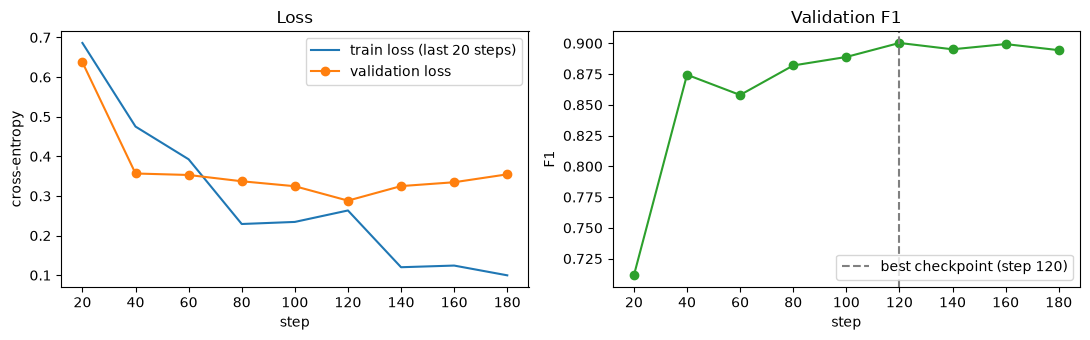

In [40]:
history_s8 = pd.DataFrame(state.log_history)
train_curve = history_s8.dropna(subset=["loss"])[["step", "loss"]]
eval_curve = history_s8.dropna(subset=["eval_f1"])[["step", "eval_loss", "eval_accuracy", "eval_f1"]]
print(eval_curve.round(4).to_string(index=False))
best_s8_step = int(Path(state.best_model_checkpoint).name.split("-")[-1])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(train_curve["step"], train_curve["loss"], label="train loss (last 20 steps)")
axes[0].plot(eval_curve["step"], eval_curve["eval_loss"], marker="o", label="validation loss")
axes[0].set(xlabel="step", ylabel="cross-entropy", title="Loss")
axes[0].legend()
axes[1].plot(eval_curve["step"], eval_curve["eval_f1"], marker="o", color="tab:green")
axes[1].axvline(best_s8_step, ls="--", color="gray", label=f"best checkpoint (step {best_s8_step})")
axes[1].set(xlabel="step", ylabel="F1", title="Validation F1")
axes[1].legend()
plt.tight_layout()
plt.show()

In [41]:
val_metrics_s8 = trainer_s8.evaluate()            # the model now holds the BEST checkpoint's weights
print({k: round(v, 4) for k, v in val_metrics_s8.items() if k in ("eval_loss", "eval_accuracy", "eval_f1")})

S8_MODEL_DIR = OUTPUT_DIR / "sst2_distilbert_best"
trainer_s8.save_model(str(S8_MODEL_DIR))           # weights + config (with id2label) + tokenizer files
probe_sentences = list(val_ds["sentence"][:4])
with torch.inference_mode():
    probe_inputs = bert_tok(probe_sentences, padding=True, return_tensors="pt").to(trainer_s8.model.device)
    reference_logits = trainer_s8.model.eval()(**probe_inputs).logits.cpu()
print("saved to", S8_MODEL_DIR, "| the test set has not been touched")

{'eval_loss': 0.2881, 'eval_accuracy': 0.891, 'eval_f1': 0.9003}


saved to _outputs/hf_transformers/sst2_distilbert_best | the test set has not been touched


### ✍️ Your Turn

From `trainer_s8.state.log_history`, find the **step with the highest `eval_f1`** (the first one if there is a tie) and store it as an `int` in `best_step`.

In [42]:
best_step = None  # TODO: your code here
check("best_step", best_step, best_s8_step,
      hint="Keep entries that contain 'eval_f1', then max(entries, key=lambda e: e['eval_f1'])['step'].")

⏳ best_step: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
evals = [entry for entry in trainer_s8.state.log_history if "eval_f1" in entry]
best_step = int(max(evals, key=lambda entry: entry["eval_f1"])["step"])
check("best_step", best_step, best_s8_step)
```

`max` returns the first maximal element, matching how `Trainer` only replaces the best checkpoint on a **strict** improvement.
</details>

In [43]:
del trainer_s8, model_s8
free_memory()

> 💡 **Interview angle:** "Fine-tuning vs feature extraction vs prompting?" — **prompting** a large model: no labels, fastest to try, but expensive per request and harder to control. **Feature extraction** (frozen embeddings + a small classifier): cheap, good with few labels. **Fine-tuning** a small encoder: needs a few thousand labels, but gives the best accuracy per dollar and millisecond at high volume.

## 9. Token Classification (NER) and Label Alignment 🔴

**Named-entity recognition (NER)** tags each word: person, organization, location, miscellaneous. Tags use the **BIO** scheme: `B-` begins an entity, `I-` continues it, `O` is outside any entity.

The catch: the dataset labels **words**, but the model predicts **tokens**, and one word can become several tokens.

```
words :  Hugging    Face     opened  …  Paris
labels:  B-ORG      I-ORG    O          B-LOC
tokens:  [CLS] hugging face opened … paris [SEP]         word_ids: None 0 1 2 … 6 None
```

**Rule:** give each word's label to its **first** token, and `-100` to special tokens and later sub-tokens. PyTorch's cross-entropy ignores `-100`, so each word is counted once.

We use **CoNLL-2003** (Reuters news, 2003), loaded from a Parquet mirror on the Hub that needs no custom loading script. The data comes from Reuters and is meant for research use — check the dataset card before using it commercially.

In [44]:
from transformers import AutoModelForTokenClassification, DataCollatorForTokenClassification

conll = load_dataset("tomaarsen/conll2003")
ner_names = conll["train"].features["ner_tags"].feature.names
print(conll)
print("tags:", ner_names)
first = conll["train"][0]
print(list(zip(first["tokens"], [ner_names[t] for t in first["ner_tags"]])))

DatasetDict({
    train: Dataset({
        features: ['id', 'document_id', 'sentence_id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'document_id', 'sentence_id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'document_id', 'sentence_id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})
tags: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
[('EU', 'B-ORG'), ('rejects', 'O'), ('German', 'B-MISC'), ('call', 'O'), ('to', 'O'), ('boycott', 'O'), ('British', 'B-MISC'), ('lamb', 'O'), ('.', 'O')]


In [45]:
words = ["Hugging", "Face", "opened", "an", "office", "in", "Montréal", "."]
word_tags = ["B-ORG", "I-ORG", "O", "O", "O", "O", "B-LOC", "O"]
enc_words = bert_tok(words, is_split_into_words=True)      # input is already split into words

aligned, previous = [], None
for wid in enc_words.word_ids():
    if wid is None:
        aligned.append("-100 (special)")
    elif wid != previous:
        aligned.append(word_tags[wid])
    else:
        aligned.append("-100 (later sub-token)")
    previous = wid
pd.DataFrame({"token": enc_words.tokens(), "word_id": enc_words.word_ids(), "label": aligned}, dtype=object).T

,0,1,2,3,4,5,6,7,8,9
token,[CLS],hugging,face,opened,an,office,in,montreal,.,[SEP]
word_id,None,0,1,2,3,4,5,6,7,None
label,-100 (special),B-ORG,I-ORG,O,O,O,O,B-LOC,O,-100 (special)


In [46]:
def tokenize_and_align(batch):
    enc = bert_tok(batch["tokens"], is_split_into_words=True, truncation=True, max_length=128)
    all_labels = []
    for i, tags in enumerate(batch["ner_tags"]):
        labels, previous = [], None
        for wid in enc.word_ids(batch_index=i):
            labels.append(-100 if wid is None or wid == previous else tags[wid])
            previous = wid
        all_labels.append(labels)
    enc["labels"] = all_labels
    return enc


ner_columns = conll["train"].column_names
ner_train = conll["train"].shuffle(seed=SEED).select(range(3_000)).map(tokenize_and_align, batched=True, remove_columns=ner_columns)
ner_val = conll["validation"].shuffle(seed=SEED).select(range(600)).map(tokenize_and_align, batched=True, remove_columns=ner_columns)
ner_test = conll["test"].shuffle(seed=SEED).select(range(800)).map(tokenize_and_align, batched=True, remove_columns=ner_columns)
print(f"NER rows — train {ner_train.num_rows:,} | validation {ner_val.num_rows} | test {ner_test.num_rows}")

NER rows — train 3,000 | validation 600 | test 800


**Metric: `seqeval`.** Token accuracy is misleading because most tokens are `O`. `seqeval` scores **whole entities**: a predicted entity counts only if its type *and* its exact span match.

In [47]:
seqeval_metric = evaluate.load("seqeval")


def to_tag_lists(logits_or_preds, label_ids):
    preds = logits_or_preds.argmax(-1) if logits_or_preds.ndim == 3 else logits_or_preds
    pred_tags = [[ner_names[p] for p, l in zip(row_p, row_l) if l != -100] for row_p, row_l in zip(preds, label_ids)]
    true_tags = [[ner_names[l] for l in row_l if l != -100] for row_l in label_ids]
    return pred_tags, true_tags


def compute_ner_metrics(eval_pred):
    pred_tags, true_tags = to_tag_lists(*eval_pred)
    report = seqeval_metric.compute(predictions=pred_tags, references=true_tags)
    return {"precision": report["overall_precision"], "recall": report["overall_recall"],
            "f1": report["overall_f1"], "token_accuracy": report["overall_accuracy"]}


transformers.set_seed(SEED)
ner_model = AutoModelForTokenClassification.from_pretrained(
    ENCODER, num_labels=len(ner_names), id2label=dict(enumerate(ner_names)), label2id={n: i for i, n in enumerate(ner_names)})
ner_trainer = Trainer(
    model=ner_model,
    args=TrainingArguments(
        output_dir=str(OUTPUT_DIR / "ner_trainer"), eval_strategy="epoch", save_strategy="epoch",
        load_best_model_at_end=True, metric_for_best_model="f1", save_total_limit=1, save_only_model=True,
        num_train_epochs=2, learning_rate=5e-5, weight_decay=0.01, warmup_steps=0.1,
        per_device_train_batch_size=32, per_device_eval_batch_size=128, logging_strategy="epoch",
        report_to="none", disable_tqdm=True, seed=SEED, dataloader_pin_memory=False),
    train_dataset=ner_train, eval_dataset=ner_val, processing_class=bert_tok,
    data_collator=DataCollatorForTokenClassification(bert_tok),   # pads input_ids AND labels (with -100)
    compute_metrics=compute_ner_metrics,
)
ner_trainer.remove_callback(PrinterCallback)
start = time.perf_counter()
ner_trainer.train()
print(f"NER training: {time.perf_counter() - start:.0f}s")
print(pd.DataFrame(ner_trainer.state.log_history).dropna(subset=["eval_f1"])[["epoch", "eval_loss", "eval_f1", "eval_token_accuracy"]].round(4).to_string(index=False))

NER training: 50s
 epoch  eval_loss  eval_f1  eval_token_accuracy
   1.0     0.0906   0.8490               0.9760
   2.0     0.0677   0.8778               0.9805


The best epoch was chosen on validation. Now the **test** set, once:

In [48]:
test_out = ner_trainer.predict(ner_test)
pred_tags, true_tags = to_tag_lists(test_out.predictions, test_out.label_ids)
report = seqeval_metric.compute(predictions=pred_tags, references=true_tags)
per_type = pd.DataFrame({k: v for k, v in report.items() if isinstance(v, dict)}).T.astype(float)
print(per_type.round(3))

all_true = [t for row in true_tags for t in row]
all_o_accuracy = np.mean([t == "O" for t in all_true])
print(f"\nentity-level F1: {report['overall_f1']:.3f} | token accuracy: {report['overall_accuracy']:.3f} | "
      f"'predict O everywhere' token accuracy: {all_o_accuracy:.3f}")
print(f"→ a model that finds zero entities already scores {all_o_accuracy:.0%} token accuracy, which is why NER reports entity F1.")
print(f"weakest entity type on test: {per_type['f1'].idxmin()} (F1 {per_type['f1'].min():.3f})")

      precision  recall     f1  number
LOC       0.854   0.872  0.863   376.0
MISC      0.640   0.728  0.681   151.0
ORG       0.759   0.810  0.784   385.0
PER       0.954   0.935  0.944   398.0

entity-level F1: 0.841 | token accuracy: 0.969 | 'predict O everywhere' token accuracy: 0.821
→ a model that finds zero entities already scores 82% token accuracy, which is why NER reports entity F1.
weakest entity type on test: MISC (F1 0.681)


In [49]:
ner_pipe = pipeline("token-classification", model=ner_trainer.model, tokenizer=bert_tok,
                    aggregation_strategy="first", device=DEVICE)       # merge sub-tokens back into words/entities
for entity in ner_pipe("Satya Nadella said Microsoft will open a new research lab in Nairobi with the University of Nairobi."):
    print(f"{entity['entity_group']:5s} {entity['word']:28s} {float(entity['score']):.3f}")

PER   satya nadella                0.966
ORG   microsoft                    0.901
LOC   nairobi                      0.983
ORG   university of                0.660
LOC   nairobi                      0.428


Notice the entity words come back **lowercased**: we used an *uncased* model to save a download. Capital letters are a strong NER clue, so in practice prefer a **cased** encoder for NER.

### ✍️ Your Turn

Write `align_first_subword(word_ids, word_labels)` returning one label per token: the word's label on its **first** token, `-100` on special tokens (`None`) and on later sub-tokens.

In [50]:
def align_first_subword(word_ids, word_labels):
    return None  # TODO: your code here


check("align_first_subword", align_first_subword([None, 0, 1, 1, 2, None], [3, 0, 7]), [-100, 3, 0, -100, 7, -100],
      hint="Track the previous word id; emit word_labels[wid] only when wid is not None and differs from the previous one.")

⏳ align_first_subword: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def align_first_subword(word_ids, word_labels):
    labels, previous = [], None
    for wid in word_ids:
        labels.append(-100 if wid is None or wid == previous else word_labels[wid])
        previous = wid
    return labels


check("align_first_subword", align_first_subword([None, 0, 1, 1, 2, None], [3, 0, 7]), [-100, 3, 0, -100, 7, -100])
```

A common alternative labels **every** sub-token (converting later `B-X` pieces to `I-X`); then you must pick one prediction per word at inference.
</details>

In [51]:
del ner_trainer, ner_model, ner_pipe
free_memory()

> 💡 **Interview angle:** "How do you align word-level NER labels with subword tokens?" — tokenize with `is_split_into_words=True`, use `word_ids()`, label the first sub-token, set the rest and special tokens to `-100` so the loss ignores them, and evaluate with entity-level `seqeval` F1 rather than token accuracy.

## 10. Text Generation with a Small Instruct Model 🟡

A **base** decoder only continues text. An **instruct** (chat) model was further trained on conversations, so it answers requests. Each chat model expects its conversation in a specific text format with special tokens — its **chat template**. Never build that string by hand: `tokenizer.apply_chat_template(messages)` renders it exactly as the model saw during training.

**Generation settings:**

| Setting | Effect |
|---|---|
| `max_new_tokens` | hard cap on output length (always set it) |
| `do_sample=False` | **greedy**: always pick the most likely token → deterministic |
| `do_sample=True` + `temperature` | divide logits by T before softmax: T<1 sharper/safer, T>1 flatter/more random |
| `top_k` / `top_p` | sample only from the k most likely tokens / the smallest set whose probability reaches p |
| `repetition_penalty` | discourage repeating tokens |
| EOS token, `stop_strings` | end generation early |

We use **SmolLM2-135M-Instruct** — tiny enough for any laptop, so expect simple and sometimes wrong answers.

In [52]:
gen_dtype = torch.bfloat16 if DEVICE in ("mps", "cuda") else torch.float32    # half precision is slow on most CPUs (Section 12)
chat_model = AutoModelForCausalLM.from_pretrained(CHAT_MODEL, dtype=gen_dtype).to(DEVICE).eval()

messages = [
    {"role": "system", "content": "You are a concise assistant for machine-learning students."},
    {"role": "user", "content": "In two sentences, what does a tokenizer do?"},
]
prompt_text = chat_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print(prompt_text)
chat_inputs = chat_tok.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt", return_dict=True).to(DEVICE)
print("prompt length:", chat_inputs["input_ids"].shape[1], "tokens")

<|im_start|>system
You are a concise assistant for machine-learning students.<|im_end|>
<|im_start|>user
In two sentences, what does a tokenizer do?<|im_end|>
<|im_start|>assistant

prompt length: 35 tokens


`add_generation_prompt=True` appends the `<|im_start|>assistant` header, telling the model it is its turn to speak.

In [53]:
def generate_reply(inputs, **generation_kwargs):
    with torch.inference_mode():
        output = chat_model.generate(**inputs, pad_token_id=chat_tok.pad_token_id, **generation_kwargs)
    new_tokens = output[0, inputs["input_ids"].shape[1]:]          # drop the prompt tokens
    return chat_tok.decode(new_tokens, skip_special_tokens=True), len(new_tokens)


greedy_1, n_greedy = generate_reply(chat_inputs, max_new_tokens=80, do_sample=False)
greedy_2, _ = generate_reply(chat_inputs, max_new_tokens=80, do_sample=False)
print(f"[greedy, {n_greedy} new tokens]\n{greedy_1}\n")
print("greedy is deterministic:", greedy_1 == greedy_2)

[greedy, 29 new tokens]
A tokenizer is a programming language-agnostic tool that breaks down text into smaller, manageable chunks, allowing for more efficient processing and analysis.

greedy is deterministic: True


**Temperature, visualized** on five made-up logits (a controlled example):

In [54]:
toy_logits = torch.tensor([3.0, 2.0, 1.0, 0.5, 0.0])
for T in [0.3, 1.0, 2.0]:
    p = (toy_logits / T).softmax(-1)
    print(f"T={T}: probabilities {p.numpy().round(3)} | top token share {p.max():.2f}")

T=0.3: probabilities [0.964 0.034 0.001 0.    0.   ] | top token share 0.96
T=1.0: probabilities [0.612 0.225 0.083 0.05  0.03 ] | top token share 0.61
T=2.0: probabilities [0.403 0.244 0.148 0.115 0.09 ] | top token share 0.40


In [55]:
for temperature in [0.3, 1.3]:
    replies = []
    for seed in range(3):
        transformers.set_seed(seed)
        reply, _ = generate_reply(chat_inputs, max_new_tokens=40, do_sample=True, temperature=temperature, top_p=0.9, top_k=50)
        replies.append(reply)
    print(f"temperature={temperature}: {len(set(replies))} distinct replies out of 3")
    for r in replies:
        print("   •", r.replace("\n", " ")[:160])

temperature=0.3: 3 distinct replies out of 3
   • A tokenizer is a machine learning algorithm that breaks down text into smaller, manageable chunks, allowing it to learn and improve its performance on a specifi
   • A tokenizer is a programming language-agnostic tool that breaks down text into individual words, allowing for efficient processing and manipulation of text data
   • A tokenizer is a programming language-agnostic tool that breaks down text into smaller, manageable chunks, allowing for efficient processing and manipulation of


temperature=1.3: 3 distinct replies out of 3
   • The **tokenizer** converts pre-trained text into low-level, flexible data structures that can easily be manipulated by machine learning algorithms. It helps to 
   • A tokenizer, also known as document pre-processing, separates text from metadata, allowing for easier extraction of relevant data such as dates, pages, or other
   • A tokenizer, or tokenization, is a machine-learning layer that breaks down words and features into manageable segments, such as alphabets, numbers, punctuation,


**Stopping.** Generation ends at `max_new_tokens`, at the model's end-of-sequence token, or at any string in `stop_strings` (which needs the tokenizer passed in):

In [56]:
eos_ids = chat_model.generation_config.eos_token_id
print("EOS token id:", eos_ids, "=", chat_tok.convert_ids_to_tokens(eos_ids))
first_clause, n_first = generate_reply(chat_inputs, max_new_tokens=200, do_sample=False, stop_strings=[","], tokenizer=chat_tok)
print(f"stop_strings=[','] → {n_first} tokens instead of {n_greedy}: {first_clause!r}")

EOS token id: 2 = <|im_end|>


stop_strings=[','] → 17 tokens instead of 29: 'A tokenizer is a programming language-agnostic tool that breaks down text into smaller,'


In [57]:
from transformers import GenerationConfig

creative = GenerationConfig(max_new_tokens=60, do_sample=True, temperature=0.8, top_p=0.95, repetition_penalty=1.1,
                            eos_token_id=eos_ids, pad_token_id=chat_tok.pad_token_id)     # reusable, saveable settings
transformers.set_seed(SEED)
with torch.inference_mode():
    out = chat_model.generate(**chat_inputs, generation_config=creative)
print(chat_tok.decode(out[0, chat_inputs["input_ids"].shape[1]:], skip_special_tokens=True))

A tokenizer is a component in a neural network that breaks down text into smaller pieces called tokens (e.g., words, phrases) and then analyzes them to identify important features or patterns within the data. It helps extract meaningful information from large datasets by isolating distinct elements of written content, enabling more accurate


### ✍️ Your Turn

Create `my_messages`: a **system** message and a **user** message of your choice. The check renders it with the chat template and verifies the prompt has three turns (system, user, assistant header) and ends with the assistant header.

In [58]:
my_messages = None  # TODO: your code here
rendered = None if my_messages is None else chat_tok.apply_chat_template(my_messages, tokenize=False, add_generation_prompt=True)
check("chat_prompt_ready",
      None if rendered is None else (rendered.count("<|im_start|>") == 3 and rendered.endswith("<|im_start|>assistant\n")), True,
      hint="A list of two dicts with 'role' ('system', then 'user') and 'content'.")

⏳ chat_prompt_ready: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
my_messages = [
    {"role": "system", "content": "You explain things to a 10-year-old."},
    {"role": "user", "content": "Why do language models need tokenizers?"},
]
rendered = chat_tok.apply_chat_template(my_messages, tokenize=False, add_generation_prompt=True)
check("chat_prompt_ready", rendered.count("<|im_start|>") == 3 and rendered.endswith("<|im_start|>assistant\n"), True)
```

Each model family has its own template (Llama 3, Qwen, and Mistral all differ) — `apply_chat_template` keeps your code the same across them.
</details>

In [59]:
del chat_model
free_memory()

> 💡 **Interview angle:** "Temperature vs top-p?" — temperature reshapes the whole distribution; top-p cuts off the unlikely tail so sampling never picks nonsense tokens. Use greedy or low temperature for extraction and classification, higher temperature with top-p for creative text, and always cap `max_new_tokens`.

## 11. LoRA with peft — A First Look 🔴

Full fine-tuning updates **all** 67M weights and needs optimizer state for each. **LoRA** (Low-Rank Adaptation) freezes the pretrained weight matrix $W \in \mathbb{R}^{d \times k}$ and learns a small update made of two thin matrices:

$$h = W x + \frac{\alpha}{r} \, B A x, \qquad A \in \mathbb{R}^{r \times k},\; B \in \mathbb{R}^{d \times r},\; r \ll \min(d, k)$$

```
  x ──► [ W  (frozen, 768×768 = 589,824) ] ─────────────┐
  │                                                     (+) ──► h
  └──► [ A (8×768) ] ──► [ B (768×8) ] ──► × α/r ───────┘      trainable: 8·(768+768) = 12,288
```

- **`r` (rank)** — size of the bottleneck; bigger = more capacity and more parameters.
- **`lora_alpha`** — scales the update by α/r, so changing `r` doesn't force you to retune the learning rate.
- **`target_modules`** — which linear layers get adapters. The LoRA paper adapted attention query/value projections; today "all linear layers" is common for LLMs.
- `B` starts at **zero**, so training starts exactly from the pretrained model.
- After training you can **merge**: $W' = W + \frac{\alpha}{r}BA$ → no extra inference cost.

This is an introduction; QLoRA, adapter serving, and DPO are covered in [Fine-Tuning with LoRA and DPO](../08_Generative_AI_LLM/07_Fine_Tuning_LoRA_and_DPO.ipynb).

In [60]:
from peft import LoraConfig, TaskType, get_peft_model

transformers.set_seed(SEED)
base_for_lora = AutoModelForSequenceClassification.from_pretrained(ENCODER, num_labels=2, id2label=id2label, label2id=label2id)
print("DistilBERT attention projections:", base_for_lora.distilbert.transformer.layer[0].attention)

lora_config = LoraConfig(task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.1, target_modules=["q_lin", "v_lin"])
lora_model = get_peft_model(base_for_lora, lora_config)
lora_model.print_trainable_parameters()

trainable = {name: p.numel() for name, p in lora_model.named_parameters() if p.requires_grad}
lora_part = sum(n for name, n in trainable.items() if "lora_" in name)
head_part = sum(n for name, n in trainable.items() if "lora_" not in name)
print(f"LoRA matrices : {lora_part:,} = 6 layers × 2 modules × 8·(768+768) = {6 * 2 * 8 * (768 + 768):,}")
print(f"trainable head: {head_part:,} (task_type=SEQ_CLS marks the new classifier as modules_to_save)")
print("adapted layer :", lora_model.base_model.model.distilbert.transformer.layer[0].attention.q_lin)

DistilBERT attention projections: DistilBertSelfAttention(
  (q_lin): Linear(in_features=768, out_features=768, bias=True)
  (k_lin): Linear(in_features=768, out_features=768, bias=True)
  (v_lin): Linear(in_features=768, out_features=768, bias=True)
  (out_lin): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925
LoRA matrices : 147,456 = 6 layers × 2 modules × 8·(768+768) = 147,456
trainable head: 592,130 (task_type=SEQ_CLS marks the new classifier as modules_to_save)
adapted layer : lora.Linear(
  (base_layer): Linear(in_features=768, out_features=768, bias=True)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.1, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=768, out_features=8, bias=False)
  )
  (lora_B): ModuleDict(
    (default): Linear(in_features=8, out_features=768, bias=False)
  )
  (lora_embedding_A): ParameterDict()


Train it on the same 2,000 rows and validation set as Section 8. LoRA usually needs a **larger learning rate** (here 10×) because the update starts from zero and has few parameters.

In [61]:
lora_trainer = Trainer(
    model=lora_model,
    args=TrainingArguments(
        output_dir=str(OUTPUT_DIR / "sst2_lora_trainer"), eval_strategy="steps", eval_steps=20, save_strategy="steps", save_steps=20,
        load_best_model_at_end=True, metric_for_best_model="f1", save_total_limit=1, save_only_model=True,
        num_train_epochs=3, learning_rate=5e-4, weight_decay=0.01, warmup_steps=0.1,
        per_device_train_batch_size=32, per_device_eval_batch_size=128, logging_steps=20,
        report_to="none", disable_tqdm=True, seed=SEED, dataloader_pin_memory=False),
    train_dataset=small_train, eval_dataset=val_tok, processing_class=bert_tok, data_collator=collator,
    compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
lora_trainer.remove_callback(PrinterCallback)
start = time.perf_counter()
lora_trainer.train()
lora_seconds = time.perf_counter() - start
val_metrics_lora = lora_trainer.evaluate()
print(f"LoRA: {lora_seconds:.0f}s | validation accuracy {val_metrics_lora['eval_accuracy']:.4f} | F1 {val_metrics_lora['eval_f1']:.4f}")
print(f"full fine-tuning (Section 8): {s8_seconds:.0f}s | validation accuracy {val_metrics_s8['eval_accuracy']:.4f} | F1 {val_metrics_s8['eval_f1']:.4f}")

LoRA: 39s | validation accuracy 0.8800 | F1 0.8913
full fine-tuning (Section 8): 63s | validation accuracy 0.8910 | F1 0.9003


**Save the adapter, then merge.** The adapter file holds only the trained parameters. Merging folds `BA` into `W`, giving an ordinary model with identical outputs:

In [62]:
lora_model = lora_trainer.model.eval()
adapter_dir = OUTPUT_DIR / "sst2_lora_adapter"
lora_model.save_pretrained(str(adapter_dir))
adapter_mb = sum(f.stat().st_size for f in adapter_dir.glob("*.safetensors")) / 1e6
full_mb = (S8_MODEL_DIR / "model.safetensors").stat().st_size / 1e6

with torch.inference_mode():
    before_merge = lora_model(**probe_inputs.to(lora_model.device)).logits.float().cpu()
merged_model = lora_model.merge_and_unload()
with torch.inference_mode():
    after_merge = merged_model(**probe_inputs.to(merged_model.device)).logits.float().cpu()

print(f"adapter file {adapter_mb:.1f} MB (LoRA + head) vs full model {full_mb:.0f} MB → {full_mb / adapter_mb:.0f}× smaller")
print(f"max logit change after merge: {(before_merge - after_merge).abs().max().item():.1e}")
print("merged model class:", type(merged_model).__name__, "| any LoRA parameters left:",
      any("lora_" in name for name, _ in merged_model.named_parameters()))
assert torch.allclose(before_merge, after_merge, atol=1e-4)

adapter file 3.0 MB (LoRA + head) vs full model 268 MB → 90× smaller
max logit change after merge: 1.8e-06
merged model class: DistilBertForSequenceClassification | any LoRA parameters left: False


In [63]:
del lora_trainer, lora_model, merged_model, base_for_lora
free_memory()

> 💡 **Interview angle:** "Explain LoRA's rank and alpha." — rank `r` is the width of the low-rank bottleneck (trainable params per matrix = r·(d+k)); alpha scales the update by α/r; `B` is zero-initialized so training starts from the base model; adapters can be merged for zero added latency or kept separate to serve many tasks from one base model.

## 12. Inference Efficiency: Batching, inference_mode, and dtypes 🟡

Three cheap levers, measured instead of assumed:

1. **Batching** — one forward pass over many texts uses the hardware in parallel.
2. **`torch.inference_mode()`** — no autograd bookkeeping (like `no_grad`, slightly faster, tensors can't be used for backward later).
3. **Precision (dtype)** — float16/bfloat16 halve memory and are often faster **on GPUs and Apple MPS**, but on most CPUs they can be *slower*. Sorting texts by length also cuts padding.

We time the ready-made sentiment model on 512 real SST-2 sentences that none of our experiments use. Timings depend on your machine; the conclusions are computed from whatever you measure.

In [64]:
rest_of_train = sst2["train"].shuffle(seed=SEED).select(range(6_000, 26_000))       # rows outside our 6,000-row pool
timing_texts = [s for s in rest_of_train["sentence"] if len(s.split()) >= 12][:512]
eff_tok = AutoTokenizer.from_pretrained(SENTIMENT_MODEL)


def timed_predictions(model, device, texts, batch_size, sort_by_length=False, grad=False):
    order = sorted(range(len(texts)), key=lambda i: len(texts[i])) if sort_by_length else list(range(len(texts)))
    preds = np.empty(len(texts), dtype=int)
    context = torch.enable_grad() if grad else torch.inference_mode()
    if device == "mps":
        torch.mps.synchronize()
    if device == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    with context:
        for i in range(0, len(order), batch_size):
            idx = order[i:i + batch_size]
            batch = eff_tok([texts[j] for j in idx], padding=True, truncation=True, return_tensors="pt").to(device)
            preds[idx] = model(**batch).logits.argmax(-1).cpu().numpy()
    if device == "mps":
        torch.mps.synchronize()
    if device == "cuda":
        torch.cuda.synchronize()
    return time.perf_counter() - start, preds


configs = [  # (device, dtype, batch size, sort by length, gradients on, number of texts)
    (DEVICE, torch.float32, 1, False, False, 128),
    (DEVICE, torch.float32, 64, False, True, 512),
    (DEVICE, torch.float32, 64, False, False, 512),
    (DEVICE, torch.float32, 64, True, False, 512),
]
if DEVICE != "cpu":
    configs += [(DEVICE, torch.float16, 64, True, False, 512), (DEVICE, torch.bfloat16, 64, True, False, 512)]
configs += [("cpu", torch.float32, 64, True, False, 128), ("cpu", torch.bfloat16, 64, True, False, 128)]

timing_rows, reference_preds, loaded = [], None, {}
for device, dtype, bs, sort, grad, n in configs:
    key = (device, dtype)
    if key not in loaded:
        loaded.clear()
        free_memory()
        loaded[key] = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL, dtype=dtype).to(device).eval()
        timed_predictions(loaded[key], device, timing_texts[:64], 64)                 # warm-up (kernel compilation)
    seconds, preds = timed_predictions(loaded[key], device, timing_texts[:n], bs, sort, grad)
    if reference_preds is None and bs == 64 and dtype == torch.float32 and device == DEVICE and not grad:
        reference_preds = preds
    timing_rows.append({"device": device, "dtype": str(dtype).replace("torch.", ""), "batch": bs, "sorted": sort,
                        "grad": grad, "texts": n, "sentences_per_s": n / seconds, "preds": preds,
                        "memory_MB": loaded[key].get_memory_footprint() / 1e6})
loaded.clear()
free_memory()

timing = pd.DataFrame(timing_rows)
timing["agree_with_fp32"] = [float(np.mean(preds == reference_preds[:n])) for preds, n in zip(timing["preds"], timing["texts"])]
timing["config"] = [f"{d} {dt} bs={b}{' sorted' if s else ''}{' +grad' if g else ''}"
                    for d, dt, b, s, g in zip(timing["device"], timing["dtype"], timing["batch"], timing["sorted"], timing["grad"])]
print(timing[["config", "texts", "sentences_per_s", "memory_MB", "agree_with_fp32"]].round(2).to_string(index=False))

                   config  texts  sentences_per_s  memory_MB  agree_with_fp32
         mps float32 bs=1    128            68.05     267.82              1.0
  mps float32 bs=64 +grad    512           321.42     267.82              1.0
        mps float32 bs=64    512           448.81     267.82              1.0
 mps float32 bs=64 sorted    512           570.56     267.82              1.0
 mps float16 bs=64 sorted    512          1317.55     133.91              1.0
mps bfloat16 bs=64 sorted    512          1305.06     133.91              1.0
 cpu float32 bs=64 sorted    128            98.18     267.82              1.0
cpu bfloat16 bs=64 sorted    128            18.02     133.91              1.0


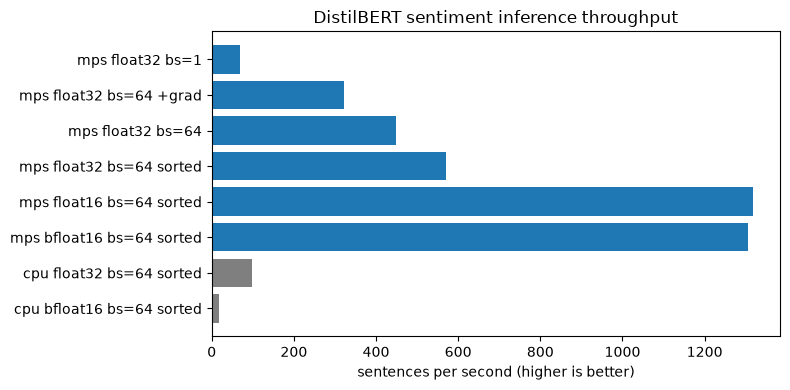

batching (64 vs 1)             : 6.6× faster on mps
inference_mode vs gradients on : 1.40×
sorting by length              : 1.27×
float16 vs float32 on mps      : 2.31×
bfloat16 vs float32 on CPU     : 0.18× → SLOWER on this CPU — always measure
lowest prediction agreement with float32: 1.000


In [65]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(timing["config"], timing["sentences_per_s"], color=["tab:gray" if d == "cpu" else "tab:blue" for d in timing["device"]])
ax.set(xlabel="sentences per second (higher is better)", title="DistilBERT sentiment inference throughput")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


def throughput(device, dtype, batch, sorted_, grad=False):
    row = timing[(timing["device"] == device) & (timing["dtype"] == dtype) & (timing["batch"] == batch)
                 & (timing["sorted"] == sorted_) & (timing["grad"] == grad)]
    return float(row["sentences_per_s"].iloc[0])


print(f"batching (64 vs 1)             : {throughput(DEVICE, 'float32', 64, False) / throughput(DEVICE, 'float32', 1, False):.1f}× faster on {DEVICE}")
print(f"inference_mode vs gradients on : {throughput(DEVICE, 'float32', 64, False) / throughput(DEVICE, 'float32', 64, False, grad=True):.2f}×")
print(f"sorting by length              : {throughput(DEVICE, 'float32', 64, True) / throughput(DEVICE, 'float32', 64, False):.2f}×")
if DEVICE != "cpu":
    print(f"float16 vs float32 on {DEVICE:4s}     : {throughput(DEVICE, 'float16', 64, True) / throughput(DEVICE, 'float32', 64, True):.2f}×")
cpu_ratio = throughput("cpu", "bfloat16", 64, True) / throughput("cpu", "float32", 64, True)
print(f"bfloat16 vs float32 on CPU     : {cpu_ratio:.2f}× → {'faster' if cpu_ratio > 1 else 'SLOWER'} on this CPU — always measure")
print(f"lowest prediction agreement with float32: {timing.agree_with_fp32.min():.3f}")

> 💡 **Interview angle:** "How would you speed up transformer inference?" — batch (dynamic batching in a server), sort/bucket by length, `inference_mode`, half precision on GPU/MPS (check accuracy agreement), then heavier options: int8 quantization or ONNX Runtime on CPU, distillation into a smaller model, and caching. Measure throughput *and* p95 latency — batching trades one for the other.

## 13. Saving and Loading: the save_pretrained Round Trip 🟢

`save_pretrained(dir)` (or `trainer.save_model(dir)`) writes everything `from_pretrained(dir)` needs: `config.json` (architecture **and** `id2label`), `model.safetensors`, and — when the tokenizer is saved too — its files. A local folder works everywhere a Hub repo name does. `push_to_hub()` uploads the same folder to the Hub (not run here).

In [66]:
for f in sorted(S8_MODEL_DIR.iterdir()):
    print(f"{f.name:28s} {f.stat().st_size / 1e6:8.2f} MB")
saved_config = json.loads((S8_MODEL_DIR / "config.json").read_text())
print("\nid2label in config.json:", saved_config["id2label"], "| architectures:", saved_config["architectures"])

config.json                      0.00 MB
model.safetensors              267.83 MB
tokenizer.json                   0.71 MB
tokenizer_config.json            0.00 MB
training_args.bin                0.01 MB

id2label in config.json: {'0': 'negative', '1': 'positive'} | architectures: ['DistilBertForSequenceClassification']


In [67]:
reloaded = AutoModelForSequenceClassification.from_pretrained(S8_MODEL_DIR).to(DEVICE).eval()
reloaded_tok = AutoTokenizer.from_pretrained(S8_MODEL_DIR)
with torch.inference_mode():
    new_logits = reloaded(**reloaded_tok(probe_sentences, padding=True, return_tensors="pt").to(DEVICE)).logits.cpu()
print(f"max |logit difference| after the round trip: {(new_logits - reference_logits).abs().max().item():.1e}")
assert torch.allclose(new_logits, reference_logits, atol=1e-4)

local_pipe = pipeline("text-classification", model=str(S8_MODEL_DIR), device=DEVICE)
print(local_pipe(["What a wonderful, heartfelt film.", "A boring, lifeless mess."]))
del reloaded

max |logit difference| after the round trip: 0.0e+00
[{'label': 'positive', 'score': 0.9896684885025024}, {'label': 'negative', 'score': 0.9678987264633179}]


### ✍️ Your Turn

Use `local_pipe` to classify `"Clumsy dialogue and a plot full of holes."` and store the predicted **label string** in `local_label`.

In [68]:
local_label = None  # TODO: your code here
check("local_label", local_label, "negative", hint="local_pipe(text)[0]['label'] — the names come from id2label in config.json.")

⏳ local_label: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
local_label = local_pipe("Clumsy dialogue and a plot full of holes.")[0]["label"]
check("local_label", local_label, "negative")
```

The label reads `negative` rather than `LABEL_0` because we passed `id2label` when creating the model, and it was saved in `config.json`.
</details>

In [69]:
del local_pipe
free_memory()

> 💡 **Interview angle:** "What do you need to ship a fine-tuned model?" — the weights **and** the exact tokenizer, the config with label mappings, the pinned base-model revision, the preprocessing (max length, truncation side), and a smoke test that reloads the folder and reproduces known logits — exactly the round trip above.

## 🔧 Build It From Scratch

Two interview classics, each checked against the library: a **WordPiece tokenizer** that reproduces DistilBERT's tokens exactly, and the **training loop** that `Trainer` runs for you.

### 1) WordPiece tokenization with DistilBERT's vocabulary

BERT-style tokenization has three stages:

1. **Normalize** — drop control characters, put spaces around Chinese characters, lowercase, and remove accents (Unicode NFD splits "é" into "e" + a combining accent, which we drop).
2. **Pre-tokenize** — split on whitespace and punctuation.
3. **WordPiece** — inside each word, repeatedly take the **longest prefix that exists in the vocabulary**; pieces after the first carry `##`. If any part cannot be matched, the whole word becomes `[UNK]`.

```
"unbelievably" → longest match from the start: "un"
               → remaining "believably", with ## : "##bel"
               → remaining "ievably"             : "##ie"
               → remaining "vably"               : "##va"
               → remaining "bly"                 : "##bly"      result: un ##bel ##ie ##va ##bly
```

In [70]:
import unicodedata

vocab = bert_tok.get_vocab()                      # token string → id
print(f"vocabulary size: {len(vocab):,}")


def is_punctuation(ch):
    cp = ord(ch)
    if 33 <= cp <= 47 or 58 <= cp <= 64 or 91 <= cp <= 96 or 123 <= cp <= 126:   # every ASCII symbol counts
        return True
    return unicodedata.category(ch).startswith("P")


CJK_RANGES = [(0x4E00, 0x9FFF), (0x3400, 0x4DBF), (0x20000, 0x2A6DF), (0x2A700, 0x2B73F),
              (0x2B740, 0x2B81F), (0x2B820, 0x2CEAF), (0xF900, 0xFAFF), (0x2F800, 0x2FA1F)]


def normalize(text):
    out = []
    for ch in text:
        cp = ord(ch)
        if cp == 0 or cp == 0xFFFD or (unicodedata.category(ch).startswith("C") and ch not in "\t\n\r"):
            continue                                              # control / invisible characters
        if ch in " \t\n\r" or unicodedata.category(ch) == "Zs":
            out.append(" ")                                       # any whitespace → one kind of space
        elif any(lo <= cp <= hi for lo, hi in CJK_RANGES):
            out.append(f" {ch} ")                                 # each Chinese character becomes a word
        else:
            out.append(ch)
    decomposed = unicodedata.normalize("NFD", "".join(out).lower())
    return "".join(ch for ch in decomposed if unicodedata.category(ch) != "Mn")   # drop accents


def pre_tokenize(text):
    words, current = [], ""
    for ch in text:
        if ch == " " or is_punctuation(ch):
            if current:
                words.append(current)
                current = ""
            if ch != " ":
                words.append(ch)                                  # punctuation is its own word
        else:
            current += ch
    if current:
        words.append(current)
    return words


def wordpiece(word, vocab, unk="[UNK]", max_chars=100):
    if len(word) > max_chars:
        return [unk]
    pieces, start = [], 0
    while start < len(word):
        end, match = len(word), None
        while start < end:                                        # try the longest candidate first
            candidate = word[start:end] if start == 0 else "##" + word[start:end]
            if candidate in vocab:
                match = candidate
                break
            end -= 1
        if match is None:
            return [unk]
        pieces.append(match)
        start = end
    return pieces


def my_tokenize(text):
    return [piece for word in pre_tokenize(normalize(text)) for piece in wordpiece(word, vocab)]


def my_encode(text):
    return [vocab["[CLS]"]] + [vocab[token] for token in my_tokenize(text)] + [vocab["[SEP]"]]


print(my_tokenize("The unbelievably long queue moved slowly."))

vocabulary size: 30,522
['the', 'un', '##bel', '##ie', '##va', '##bly', 'long', 'queue', 'moved', 'slowly', '.']


In [71]:
edge_cases = ["Café naïve résumé — tokenization!!", "GPT-4o's context: 128,000 tokens?", "hello​world 東京 emoji 🤗 ok",
              "Pneumonoultramicroscopicsilicovolcanoconiosis", "x" * 120]
sentences_to_check = list(test_ds["sentence"]) + edge_cases       # text only — no labels are used here

token_mismatches = [s for s in sentences_to_check if my_tokenize(s) != bert_tok.tokenize(s)]
id_mismatches = [s for s in sentences_to_check if my_encode(s) != bert_tok(s)["input_ids"]]
assert not token_mismatches and not id_mismatches, (token_mismatches[:2], id_mismatches[:2])
print(f"✅ identical tokens and ids on all {len(sentences_to_check)} texts ({len(test_ds)} SST-2 sentences + {len(edge_cases)} edge cases)")
for s in edge_cases:
    print(f"   {s[:38]!r:42s} → {my_tokenize(s)[:9]}")

✅ identical tokens and ids on all 877 texts (872 SST-2 sentences + 5 edge cases)
   'Café naïve résumé — tokenization!!'       → ['cafe', 'naive', 'resume', '—', 'token', '##ization', '!', '!']
   "GPT-4o's context: 128,000 tokens?"        → ['gp', '##t', '-', '4', '##o', "'", 's', 'context', ':']
   'hello\u200bworld 東京 emoji 🤗 ok'           → ['hello', '##world', '東', '京', 'em', '##oj', '##i', '[UNK]', 'ok']
   'Pneumonoultramicroscopicsilicovolcanoc'   → ['p', '##ne', '##um', '##ono', '##ult', '##ram', '##ic', '##ros', '##copic']
   'xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'   → ['[UNK]']


### 2) The training loop Trainer runs for you

`Trainer` is "just" a PyTorch loop with good defaults. To reproduce it exactly on 320 rows we mirror every choice:

| Choice | Trainer setting | Manual loop |
|---|---|---|
| optimizer | `optim="adamw_torch"`, `weight_decay=0.0` | `torch.optim.AdamW(lr, weight_decay=0.0)` |
| schedule | `lr_scheduler_type="linear"`, no warm-up | `get_linear_schedule_with_warmup(opt, 0, steps)` |
| gradient clipping | `max_grad_norm=1.0` (default) | `clip_grad_norm_(…, 1.0)` |
| data order | `train_sampling_strategy="sequential"` | `DataLoader(shuffle=False)` |
| padding | the same `DataCollatorWithPadding` | same collator |
| randomness | `seed=7` (head init and dropout) | `set_seed(7)` before the model and before the loop |

20 steps | mean loss: Trainer 0.6779 vs manual 0.6779 | largest per-step difference 1.2e-07


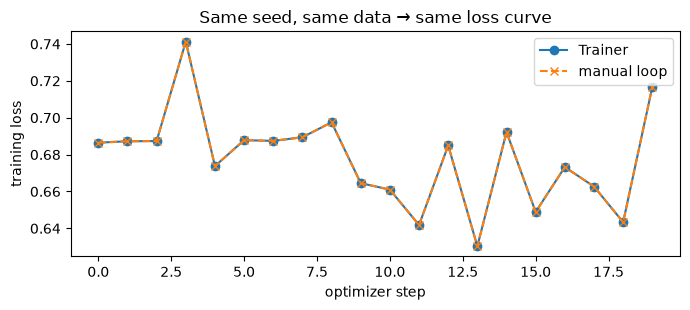

In [72]:
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup

TINY_SEED, TINY_LR, TINY_BS = 7, 5e-5, 16
tiny_train = train_ds.select(range(320)).map(tokenize_sst2, batched=True, remove_columns=["idx", "sentence"])

# A) Trainer
transformers.set_seed(TINY_SEED)
tiny_trainer = Trainer(
    model=AutoModelForSequenceClassification.from_pretrained(ENCODER, num_labels=2),
    args=TrainingArguments(
        output_dir=str(OUTPUT_DIR / "tiny_trainer"), num_train_epochs=1, learning_rate=TINY_LR,
        per_device_train_batch_size=TINY_BS, weight_decay=0.0, optim="adamw_torch", lr_scheduler_type="linear",
        warmup_steps=0, max_grad_norm=1.0, train_sampling_strategy="sequential", logging_steps=1,
        save_strategy="no", report_to="none", disable_tqdm=True, seed=TINY_SEED, dataloader_pin_memory=False),
    train_dataset=tiny_train, data_collator=collator,
)
tiny_trainer.remove_callback(PrinterCallback)
tiny_trainer.train()
trainer_losses = [entry["loss"] for entry in tiny_trainer.state.log_history if "loss" in entry]
del tiny_trainer
free_memory()

# B) the same loop by hand
transformers.set_seed(TINY_SEED)
manual_model = AutoModelForSequenceClassification.from_pretrained(ENCODER, num_labels=2).to(DEVICE)
loader = DataLoader(tiny_train, batch_size=TINY_BS, shuffle=False, collate_fn=collator)
optimizer = torch.optim.AdamW(manual_model.parameters(), lr=TINY_LR, weight_decay=0.0)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=len(loader))

transformers.set_seed(TINY_SEED)
manual_model.train()                                   # dropout ON during training
manual_losses = []
for batch in loader:
    batch = {k: v.to(DEVICE) for k, v in batch.items()}
    loss = manual_model(**batch).loss                  # passing 'labels' makes the model return cross-entropy
    loss.backward()
    torch.nn.utils.clip_grad_norm_(manual_model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()
    manual_losses.append(loss.item())
del manual_model, optimizer
free_memory()

step_diff = np.abs(np.array(trainer_losses) - np.array(manual_losses))
print(f"{len(manual_losses)} steps | mean loss: Trainer {np.mean(trainer_losses):.4f} vs manual {np.mean(manual_losses):.4f} | "
      f"largest per-step difference {step_diff.max():.1e}")
assert len(trainer_losses) == len(manual_losses) and step_diff.max() < 1e-3

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(trainer_losses, marker="o", label="Trainer")
ax.plot(manual_losses, ls="--", marker="x", label="manual loop")
ax.set(xlabel="optimizer step", ylabel="training loss", title="Same seed, same data → same loss curve")
ax.legend()
plt.tight_layout()
plt.show()

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Truncation silently drops content (and `text[:512]` counts characters)

We glue real SST-2 phrases into one long review: lots of praise, then complaints at the end (a controlled example of a mixed review).

In [73]:
sentiment = pipeline("sentiment-analysis", model=SENTIMENT_MODEL, device=DEVICE)
s_tok = sentiment.tokenizer
long_rows = [(s.strip(), y) for s, y in zip(rest_of_train["sentence"], rest_of_train["label"]) if len(s.split()) >= 15]
praise = [s for s, y in long_rows if y == 1][:45]
complaints = [s for s, y in long_rows if y == 0][:6]
long_mixed_review = " ".join(praise + complaints)
n_review_tokens = len(s_tok(long_mixed_review, add_special_tokens=False)["input_ids"])
print(f"review: {len(long_mixed_review):,} characters, {n_review_tokens:,} tokens; the last {len(complaints)} phrases are complaints")

char_cut = long_mixed_review[:512]
print(f"\n❌ text[:512] keeps only {len(s_tok(char_cut, add_special_tokens=False)['input_ids'])} tokens → {sentiment(char_cut)[0]}")
print(f"❌ truncation=True reads 510 text tokens and silently ignores {n_review_tokens - 510} → {sentiment(long_mixed_review, truncation=True)[0]}")

review_ids = s_tok(long_mixed_review, add_special_tokens=False)["input_ids"]
window_bodies = sliding_windows(review_ids, 126, 32)                     # helper from Section 4: 126 + [CLS] + [SEP]
assert covered_tokens(window_bodies, 32) == len(review_ids)               # every token is read at least once
chunks = s_tok.pad([{"input_ids": [s_tok.cls_token_id] + body + [s_tok.sep_token_id]} for body in window_bodies],
                   return_tensors="pt")
with torch.inference_mode():
    chunk_logits = sentiment.model(input_ids=chunks["input_ids"].to(DEVICE), attention_mask=chunks["attention_mask"].to(DEVICE)).logits
chunk_pos = chunk_logits.softmax(-1)[:, 1].cpu().numpy()
negative_chunks = np.flatnonzero(chunk_pos < 0.5)
print(f"\n✅ {len(chunk_pos)} overlapping 128-token chunks: {' '.join('POS' if p >= 0.5 else 'NEG' for p in chunk_pos)}")
print(f"✅ negative chunks at positions {negative_chunks.tolist()} of 0–{len(chunk_pos) - 1}; mean P(positive) {chunk_pos.mean():.2f}")
print("   → report per-chunk results (or min / mean / a learned aggregator) instead of pretending the whole text was read")

review: 6,230 characters, 1,344 tokens; the last 6 phrases are complaints

❌ text[:512] keeps only 111 tokens → {'label': 'POSITIVE', 'score': 0.9998124241828918}
❌ truncation=True reads 510 text tokens and silently ignores 834 → {'label': 'POSITIVE', 'score': 0.99977046251297}



✅ 14 overlapping 128-token chunks: POS POS POS POS POS POS POS POS POS POS POS POS NEG NEG
✅ negative chunks at positions [12, 13] of 0–13; mean P(positive) 0.86
   → report per-chunk results (or min / mean / a learned aggregator) instead of pretending the whole text was read


### ❌ Pitfall 2 — Label ↔ id mismatch

In [74]:
print("❌ no id2label given → generic names:", AutoConfig.from_pretrained(ENCODER, num_labels=2).id2label)

s8_pipe = pipeline("text-classification", model=str(S8_MODEL_DIR), device=DEVICE)


def label_accuracy(pipe, ds):
    preds = pipe(list(ds["sentence"]), batch_size=64)
    return float(np.mean([p["label"] == label_names[y] for p, y in zip(preds, ds["label"])]))


check_rows = val_ds.select(range(300))
print(f"✅ id2label built from the dataset's ClassLabel names: accuracy {label_accuracy(s8_pipe, check_rows):.3f}")
s8_pipe.model.config.id2label = {0: "positive", 1: "negative"}        # ❌ typed by hand in the wrong order
print(f"❌ hand-typed, flipped id2label                    : accuracy {label_accuracy(s8_pipe, check_rows):.3f}")
s8_pipe.model.config.id2label = id2label                               # restore

❌ no id2label given → generic names: {0: 'LABEL_0', 1: 'LABEL_1'}


✅ id2label built from the dataset's ClassLabel names: accuracy 0.877


❌ hand-typed, flipped id2label                    : accuracy 0.123


### ❌ Pitfall 3 — Evaluating on data the model trained on

In [75]:
seen_rows = train_ds.select(range(500))            # Section 8 trained on train_ds rows 0–1,999
held_out_rows = val_ds.select(range(300, 800))
acc_seen, acc_held = label_accuracy(s8_pipe, seen_rows), label_accuracy(s8_pipe, held_out_rows)
print(f"❌ accuracy on training rows : {acc_seen:.3f}")
print(f"✅ accuracy on held-out rows : {acc_held:.3f}  → training rows overstate accuracy by {acc_seen - acc_held:+.3f}")
print("   (even held-out validation is a little optimistic: it picked the checkpoint and overlaps with training phrases — the mini project reports the untouched test set)")

❌ accuracy on training rows : 0.970
✅ accuracy on held-out rows : 0.896  → training rows overstate accuracy by +0.074
   (even held-out validation is a little optimistic: it picked the checkpoint and overlaps with training phrases — the mini project reports the untouched test set)


### ❌ Pitfall 4 — Tokenizer–model mismatch

IDs only mean something with the vocabulary they came from. Feeding GPT-2 token IDs into DistilBERT often **raises no error** — it just reads different words. (Run on CPU, where an out-of-range ID raises a clear error.)

In [76]:
cpu_model = s8_pipe.model.to("cpu").eval()
review_text = "The movie was great"
right_ids = bert_tok(review_text, return_tensors="pt")["input_ids"]
wrong_ids = gpt2_tok(review_text, return_tensors="pt")["input_ids"]
with torch.inference_mode():
    p_right = cpu_model(input_ids=right_ids).logits.softmax(-1)[0, 1].item()
    p_wrong = cpu_model(input_ids=wrong_ids).logits.softmax(-1)[0, 1].item()
print(f"✅ DistilBERT tokenizer → model reads {bert_tok.convert_ids_to_tokens(right_ids[0])} → P(positive) {p_right:.3f}")
print(f"❌ GPT-2 tokenizer      → model reads {bert_tok.convert_ids_to_tokens(wrong_ids[0])} → P(positive) {p_wrong:.3f} (no error!)")
try:
    cpu_model(input_ids=gpt2_tok(" antidisestablishmentarianism", return_tensors="pt")["input_ids"])
except IndexError as err:
    print(f"❌ a GPT-2 id above DistilBERT's {cpu_model.config.vocab_size:,}-token vocabulary crashes instead: IndexError: {err}")
print("✅ guard: load tokenizer and model from the same repo/folder and revision; assert len(tokenizer) <= model.config.vocab_size →",
      len(bert_tok) <= cpu_model.config.vocab_size)
del s8_pipe, cpu_model
free_memory()

✅ DistilBERT tokenizer → model reads ['[CLS]', 'the', 'movie', 'was', 'great', '[SEP]'] → P(positive) 0.985
❌ GPT-2 tokenizer      → model reads ['[unused459]', 'twice', '[unused368]', 'm'] → P(positive) 0.730 (no error!)
❌ a GPT-2 id above DistilBERT's 30,522-token vocabulary crashes instead: IndexError: index out of range in self
✅ guard: load tokenizer and model from the same repo/folder and revision; assert len(tokenizer) <= model.config.vocab_size → True


### ❌ Pitfall 5 — Treating raw [CLS] vectors as sentence embeddings

A pretrained encoder's [CLS] vector was never trained to put similar sentences close together. A **sentence-embedding model** (trained with a contrastive objective, see [Embeddings and Semantic Search](02_Embeddings_and_Semantic_Search.ipynb)) was.

In [77]:
similarity_sentences = ["The cat sat on the mat.", "A kitten was resting on the rug.",
                        "The stock market crashed today.", "Quarterly earnings beat analyst expectations."]


def similarity_matrix(model_name, pooling):
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).eval()
    batch = tok(similarity_sentences, padding=True, return_tensors="pt")
    with torch.inference_mode():
        hidden = model(**batch).last_hidden_state
    if pooling == "cls":
        vectors = hidden[:, 0]
    else:
        m = batch["attention_mask"].unsqueeze(-1).float()
        vectors = (hidden * m).sum(1) / m.sum(1)
    vectors = torch.nn.functional.normalize(vectors, dim=-1)
    return (vectors @ vectors.T).numpy()


for label, sim in [("❌ raw DistilBERT [CLS]", similarity_matrix(ENCODER, "cls")),
                   ("✅ all-MiniLM-L6-v2 (mean)", similarity_matrix("sentence-transformers/all-MiniLM-L6-v2", "mean"))]:
    off_diagonal = sim[np.triu_indices(len(sim), k=1)]
    print(f"{label:27s} cat↔kitten {sim[0, 1]:.3f} | cat↔stock market {sim[0, 2]:.3f} | "
          f"gap {sim[0, 1] - sim[0, 2]:.3f} | lowest pair {off_diagonal.min():.3f}")
free_memory()

❌ raw DistilBERT [CLS]      cat↔kitten 0.979 | cat↔stock market 0.933 | gap 0.047 | lowest pair 0.819
✅ all-MiniLM-L6-v2 (mean)   cat↔kitten 0.625 | cat↔stock market 0.094 | gap 0.531 | lowest pair -0.009


### ❌ Pitfall 6 — Right padding in batched generation

A decoder generates from the **last** position. With right padding, the last positions of the shorter prompt are `[PAD]` tokens, so it continues from padding.

In [78]:
chat_model = AutoModelForCausalLM.from_pretrained(CHAT_MODEL, dtype=gen_dtype).to(DEVICE).eval()
questions = ["What is the capital of France?",
             "Explain in one sentence why the sky looks blue to people during the day."]
chat_prompts = [chat_tok.apply_chat_template([{"role": "user", "content": q}], tokenize=False, add_generation_prompt=True)
                for q in questions]


def first_answer(prompts, padding_side):
    chat_tok.padding_side = padding_side
    batch = chat_tok(prompts, return_tensors="pt", padding=True, add_special_tokens=False).to(DEVICE)
    with torch.inference_mode():
        out = chat_model.generate(**batch, max_new_tokens=20, do_sample=False, pad_token_id=chat_tok.pad_token_id)
    return chat_tok.decode(out[0, batch["input_ids"].shape[1]:], skip_special_tokens=True)


alone_answer = first_answer(chat_prompts[:1], "right")          # a batch of one has no padding
right_answer = first_answer(chat_prompts, "right")
left_answer = first_answer(chat_prompts, "left")
chat_tok.padding_side = "right"
print(f"prompt alone          : {alone_answer!r}")
print(f"❌ right-padded batch : {right_answer!r} | same as alone: {right_answer == alone_answer}")
print(f"✅ left-padded batch  : {left_answer!r} | same as alone: {left_answer == alone_answer}")
del chat_model
free_memory()

prompt alone          : 'The capital of France is Paris.'
❌ right-padded batch : '\n' | same as alone: False
✅ left-padded batch  : 'The capital of France is Paris.' | same as alone: True


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Count tokens
How many token IDs (special tokens included) does `bert_tok` produce for `"Hugging Face tokenizers are fast."`? Store the integer in `n_tokens`.

In [79]:
n_tokens = None  # TODO
check("n_tokens", n_tokens, 10, hint="len(bert_tok(text)['input_ids']) — look at .tokens() to see where the extra pieces come from.")

⏳ n_tokens: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_tokens = len(bert_tok("Hugging Face tokenizers are fast.")["input_ids"])
check("n_tokens", n_tokens, 10)
```
The tokens are `[CLS] hugging face token ##izer ##s are fast . [SEP]` — "tokenizers" alone needs three pieces.
</details>

### 🟢 Exercise 2 — Label mappings from a dataset
Build `ner_id2label` (int → tag) and `ner_label2id` (tag → int) from `ner_names`.

In [80]:
ner_id2label = None  # TODO
ner_label2id = None  # TODO
expected_id2label = {0: "O", 1: "B-PER", 2: "I-PER", 3: "B-ORG", 4: "I-ORG", 5: "B-LOC", 6: "I-LOC", 7: "B-MISC", 8: "I-MISC"}
check("ner_id2label", ner_id2label, expected_id2label, hint="dict(enumerate(ner_names))")
check("ner_label2id", ner_label2id, {tag: i for i, tag in expected_id2label.items()}, hint="Invert the first dict.")

⏳ ner_id2label: not attempted yet — replace None with your answer.
⏳ ner_label2id: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
ner_id2label = dict(enumerate(ner_names))
ner_label2id = {tag: i for i, tag in ner_id2label.items()}
expected_id2label = {0: "O", 1: "B-PER", 2: "I-PER", 3: "B-ORG", 4: "I-ORG", 5: "B-LOC", 6: "I-LOC", 7: "B-MISC", 8: "I-MISC"}
check("ner_id2label", ner_id2label, expected_id2label)
check("ner_label2id", ner_label2id, {tag: i for i, tag in expected_id2label.items()})
```
Deriving mappings from the dataset's `ClassLabel` (never typing them by hand) prevents Pitfall 2.
</details>

### 🟢 Exercise 3 — Masked mean pooling
Average the token vectors of each sequence in `hidden_toy` (shape `(batch, tokens, dim)`), **ignoring padded positions** where `mask_toy` is 0.

In [81]:
hidden_toy = torch.tensor([[[1.0, 2.0], [3.0, 4.0], [100.0, 100.0]],
                           [[2.0, 0.0], [4.0, 2.0], [6.0, 4.0]]])
mask_toy = torch.tensor([[1, 1, 0], [1, 1, 1]])
pooled = None  # TODO
check("pooled", pooled, [[2.0, 3.0], [4.0, 2.0]],
      hint="m = mask_toy.unsqueeze(-1).float(); (hidden_toy * m).sum(1) / m.sum(1)")

⏳ pooled: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
hidden_toy = torch.tensor([[[1.0, 2.0], [3.0, 4.0], [100.0, 100.0]],
                           [[2.0, 0.0], [4.0, 2.0], [6.0, 4.0]]])
mask_toy = torch.tensor([[1, 1, 0], [1, 1, 1]])
m = mask_toy.unsqueeze(-1).float()                 # (batch, tokens, 1) so it broadcasts over dim
pooled = (hidden_toy * m).sum(dim=1) / m.sum(dim=1)
check("pooled", pooled, [[2.0, 3.0], [4.0, 2.0]])
```
Without the mask the first row would be pulled towards the `[100, 100]` padding vector.
</details>

### 🟡 Exercise 4 — Head + tail truncation
Reviews and support tickets often put the verdict at the **end**. Write `head_tail_ids(ids, max_body, head)`: if `ids` fits in `max_body`, return it unchanged; otherwise keep the first `head` ids **and** the last `max_body - head` ids.

In [82]:
def head_tail_ids(ids, max_body, head):
    return None  # TODO


result_long, result_short = head_tail_ids(list(range(10)), 6, 2), head_tail_ids([7, 8, 9], 6, 2)
check("head_tail_ids", None if result_long is None else [result_long, result_short],
      [[0, 1, 6, 7, 8, 9], [7, 8, 9]],
      hint="ids[:head] + ids[len(ids) - (max_body - head):] — but only when len(ids) > max_body.")

⏳ head_tail_ids: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def head_tail_ids(ids, max_body, head):
    if len(ids) <= max_body:
        return list(ids)
    tail = max_body - head
    return list(ids[:head]) + list(ids[len(ids) - tail:])


result_long, result_short = head_tail_ids(list(range(10)), 6, 2), head_tail_ids([7, 8, 9], 6, 2)
check("head_tail_ids", [result_long, result_short], [[0, 1, 6, 7, 8, 9], [7, 8, 9]])
```
Add `[CLS]`/`[SEP]` afterwards, so `max_body` = model limit − 2. Keeping ~128 head tokens and ~382 tail tokens is a known strong baseline for long-review classification with BERT-style models (Sun et al., 2019, "How to Fine-Tune BERT for Text Classification?").
</details>

### 🟡 Exercise 5 — From BIO tags to entity spans
Write `bio_to_spans(tags)` returning `(entity_type, start, end)` tuples with `end` exclusive. A `B-` tag always starts a new entity; an `I-` tag continues the current entity only if the type matches (otherwise it starts a new one).

In [83]:
def bio_to_spans(tags):
    return None  # TODO


spans_a = bio_to_spans(["B-PER", "I-PER", "O", "B-LOC", "O", "B-ORG", "I-ORG", "I-ORG"])
spans_b = bio_to_spans(["B-LOC", "B-LOC", "I-LOC"])
check("bio_to_spans", None if spans_a is None else [spans_a, spans_b],
      [[("PER", 0, 2), ("LOC", 3, 4), ("ORG", 5, 8)], [("LOC", 0, 1), ("LOC", 1, 3)]],
      hint="Walk through tags + ['O']; close the open entity whenever you see O, a B- tag, or an I- tag of another type.")

⏳ bio_to_spans: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def bio_to_spans(tags):
    spans, start, kind = [], None, None
    for i, tag in enumerate(list(tags) + ["O"]):          # the sentinel "O" closes a final entity
        continues = tag.startswith("I-") and tag[2:] == kind
        if not continues:
            if kind is not None:
                spans.append((kind, start, i))
            start, kind = (i, tag[2:]) if tag != "O" else (None, None)
    return spans


spans_a = bio_to_spans(["B-PER", "I-PER", "O", "B-LOC", "O", "B-ORG", "I-ORG", "I-ORG"])
spans_b = bio_to_spans(["B-LOC", "B-LOC", "I-LOC"])
check("bio_to_spans", [spans_a, spans_b],
      [[("PER", 0, 2), ("LOC", 3, 4), ("ORG", 5, 8)], [("LOC", 0, 1), ("LOC", 1, 3)]])
```
Entity-level metrics like `seqeval` compare exactly these spans: a prediction counts only if type, start, and end all match.
</details>

### 🔴 Exercise 6 — How many parameters does LoRA train? (interview-style)
Write `lora_param_count(model, target_modules, r)`: for every `torch.nn.Linear` whose **last name component** is in `target_modules`, LoRA adds `A` (r × in_features) and `B` (out_features × r). Return the total. Check it on the DistilBERT body for two configurations.

In [84]:
def lora_param_count(model, target_modules, r):
    return None  # TODO


count_body = AutoModel.from_pretrained(ENCODER)
count_qv = lora_param_count(count_body, ["q_lin", "v_lin"], 8)
check("lora_param_count", None if count_qv is None else [count_qv, lora_param_count(count_body, ["q_lin", "k_lin", "v_lin", "out_lin"], 16)],
      [147_456, 589_824],
      hint="Loop over model.named_modules(); use name.split('.')[-1], module.in_features, module.out_features.")

⏳ lora_param_count: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def lora_param_count(model, target_modules, r):
    total = 0
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear) and name.split(".")[-1] in target_modules:
            total += r * module.in_features + module.out_features * r      # A: r×in, B: out×r
    return total


count_body = AutoModel.from_pretrained(ENCODER)
count_qv = lora_param_count(count_body, ["q_lin", "v_lin"], 8)
check("lora_param_count", [count_qv, lora_param_count(count_body, ["q_lin", "k_lin", "v_lin", "out_lin"], 16)], [147_456, 589_824])

# Cross-check against peft itself
peft_body = get_peft_model(AutoModel.from_pretrained(ENCODER),
                           LoraConfig(r=16, lora_alpha=16, target_modules=["q_lin", "k_lin", "v_lin", "out_lin"]))
check("matches peft", peft_body.get_nb_trainable_parameters()[0], 589_824)
```
6 layers × 4 matrices × 16 · (768 + 768) = 589,824 — still under 1% of the 66M-parameter body. In an interview, say the formula out loud: **r · (d_in + d_out) per adapted matrix**.
</details>

In [85]:
del count_body
free_memory()

## 🚀 Mini Project: Full Fine-Tuning vs LoRA Sentiment Classifier

**Goal:** fine-tune DistilBERT on SST-2 two ways — **all weights** vs **LoRA adapters** — on the **same** splits, select each model's checkpoint on validation, evaluate **once** on the untouched test set, and decide with evidence which one you would ship.

**Steps:** leak-free splits → tokenize → one shared training function → train both → compare validation curves → single test evaluation with a significance check → error analysis → computed conclusions.

### Step 1 — Splits without the phrase-overlap leak

Section 7 found validation phrases that appear inside training phrases. We drop them so early stopping and checkpoint selection use honest validation data.

In [86]:
project_val_raw = val_ds.filter(lambda row: f" {row['sentence'].strip()} " not in train_blob)
print(f"train {train_ds.num_rows:,} | validation {val_ds.num_rows:,} → {project_val_raw.num_rows:,} after removing overlapping phrases | test {test_ds.num_rows}")
for name, ds in [("train", train_ds), ("validation", project_val_raw), ("test", test_ds)]:
    print(f"  {name:10s} share positive {np.mean(ds['label']):.3f} | median words {np.median([len(s.split()) for s in ds['sentence']]):.0f}")

train 5,000 | validation 1,000 → 733 after removing overlapping phrases | test 872


  train      share positive 0.551 | median words 7
  validation share positive 0.558 | median words 7
  test       share positive 0.509 | median words 19


### Step 2 — Tokenize

In [87]:
project_train = train_ds.map(tokenize_sst2, batched=True, remove_columns=["idx", "sentence"])
project_val = project_val_raw.map(tokenize_sst2, batched=True, remove_columns=["idx", "sentence"])
print(project_train, project_val, sep="\n")

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 733
})


### Step 3 — One training function for both methods

Identical data, seed, batch size, epochs, schedule, early stopping, and selection metric. The only differences: LoRA wraps the model with adapters and uses a 10× larger learning rate (standard for LoRA).

In [88]:
def run_experiment(kind):
    free_memory()
    transformers.set_seed(SEED)
    model = AutoModelForSequenceClassification.from_pretrained(ENCODER, num_labels=2, id2label=id2label, label2id=label2id)
    base_params = sum(p.numel() for p in model.parameters())
    learning_rate = 5e-5
    if kind == "lora":
        model = get_peft_model(model, LoraConfig(task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.1,
                                                 target_modules=["q_lin", "v_lin"]))
        learning_rate = 5e-4
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    checkpoint_dir = OUTPUT_DIR / f"project_{kind}_checkpoints"
    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir=str(checkpoint_dir), eval_strategy="steps", eval_steps=50, save_strategy="steps", save_steps=50,
            load_best_model_at_end=True, metric_for_best_model="f1", greater_is_better=True,
            save_total_limit=1, save_only_model=True, num_train_epochs=2, learning_rate=learning_rate,
            weight_decay=0.01, warmup_steps=0.1, per_device_train_batch_size=32, per_device_eval_batch_size=128,
            logging_steps=50, report_to="none", disable_tqdm=True, seed=SEED, dataloader_pin_memory=False),
        train_dataset=project_train, eval_dataset=project_val, processing_class=bert_tok, data_collator=collator,
        compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )
    trainer.remove_callback(PrinterCallback)
    start = time.perf_counter()
    trainer.train()
    train_seconds = time.perf_counter() - start

    history = pd.DataFrame(trainer.state.log_history)
    evals = history.dropna(subset=["eval_f1"]).drop_duplicates(subset=["step"])
    best = evals.loc[evals["eval_f1"].idxmax()]
    final_dir = OUTPUT_DIR / f"project_{kind}_best"
    final_model = trainer.model.merge_and_unload() if kind == "lora" else trainer.model    # LoRA: fold adapters into W
    final_model.save_pretrained(final_dir)
    bert_tok.save_pretrained(final_dir)
    shutil.rmtree(checkpoint_dir, ignore_errors=True)                                        # checkpoints no longer needed

    summary = {"trainable_params": trainable_params, "trainable_share": trainable_params / base_params,
               "train_seconds": train_seconds, "steps": trainer.state.global_step, "best_step": int(best["step"]),
               "best_val_accuracy": float(best["eval_accuracy"]), "best_val_f1": float(best["eval_f1"]), "model_dir": str(final_dir)}
    del trainer, model, final_model
    free_memory()
    return summary, evals

### Step 4 — Train both

In [89]:
results, eval_histories = {}, {}
for kind in ["full", "lora"]:
    results[kind], eval_histories[kind] = run_experiment(kind)
    print(f"{kind:4s} done in {results[kind]['train_seconds']:.0f}s — best validation F1 {results[kind]['best_val_f1']:.4f} at step {results[kind]['best_step']}")

summary_table = pd.DataFrame(results).T.drop(columns="model_dir")
summary_table

full done in 91s — best validation F1 0.9139 at step 250


lora done in 68s — best validation F1 0.9042 at step 300


,trainable_params,trainable_share,train_seconds,steps,best_step,best_val_accuracy,best_val_f1
full,66955010,1.0,90.707053,314,250,0.905866,0.913858
lora,739586,0.011046,68.166513,314,300,0.893588,0.904177


### Step 5 — Validation curves

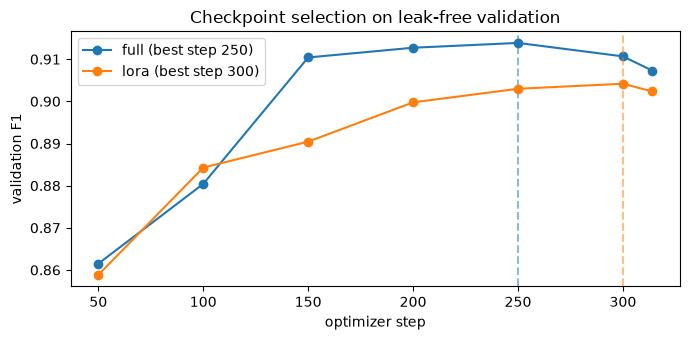

In [90]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for kind, color in [("full", "tab:blue"), ("lora", "tab:orange")]:
    h = eval_histories[kind]
    ax.plot(h["step"], h["eval_f1"], marker="o", color=color, label=f"{kind} (best step {results[kind]['best_step']})")
    ax.axvline(results[kind]["best_step"], color=color, ls="--", alpha=0.5)
ax.set(xlabel="optimizer step", ylabel="validation F1", title="Checkpoint selection on leak-free validation")
ax.legend()
plt.tight_layout()
plt.show()

### Step 6 — One evaluation on the test set

Both selected models, a majority-class baseline, and — for context only — the public SST-2 model from Section 2. That reference is **not a fair competitor**: it trained on all 67k SST-2 training rows, and SST-2's validation split (our test set) was its development set.

In [91]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score


def predict_positive_proba(model_dir, texts, batch_size=128):
    model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE).eval()
    tok = AutoTokenizer.from_pretrained(model_dir)
    chunks = []
    with torch.inference_mode():
        for i in range(0, len(texts), batch_size):
            batch = tok(texts[i:i + batch_size], padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
            chunks.append(model(**batch).logits.float().softmax(-1)[:, 1].cpu().numpy())
    del model
    free_memory()
    return np.concatenate(chunks)


test_texts, y_test = list(test_ds["sentence"]), np.array(test_ds["label"])
test_proba = {
    "full fine-tuning": predict_positive_proba(results["full"]["model_dir"], test_texts),
    "LoRA (merged)": predict_positive_proba(results["lora"]["model_dir"], test_texts),
    "reference: SST-2 model on 67k rows": predict_positive_proba(SENTIMENT_MODEL, test_texts),
}
majority_class = int(np.mean(train_ds["label"]) >= 0.5)
test_preds = {"majority class baseline": np.full(len(y_test), majority_class)}
test_preds.update({name: (p >= 0.5).astype(int) for name, p in test_proba.items()})
test_table = pd.DataFrame({name: {"accuracy": accuracy_score(y_test, pred), "f1": f1_score(y_test, pred)}
                           for name, pred in test_preds.items()}).T
print(test_table.round(4))

correct_full = test_preds["full fine-tuning"] == y_test
correct_lora = test_preds["LoRA (merged)"] == y_test
boot_idx = np.random.default_rng(SEED).integers(0, len(y_test), size=(2_000, len(y_test)))   # paired bootstrap
acc_diffs = correct_full[boot_idx].mean(axis=1) - correct_lora[boot_idx].mean(axis=1)
ci_low, ci_high = np.percentile(acc_diffs, [2.5, 97.5])
print(f"\naccuracy difference (full − LoRA): {correct_full.mean() - correct_lora.mean():+.4f} | 95% bootstrap CI [{ci_low:+.4f}, {ci_high:+.4f}]")

                                    accuracy      f1
majority class baseline               0.5092  0.6748
full fine-tuning                      0.8784  0.8812
LoRA (merged)                         0.8727  0.8746
reference: SST-2 model on 67k rows    0.9106  0.9137

accuracy difference (full − LoRA): +0.0057 | 95% bootstrap CI [-0.0103, +0.0206]


### Step 7 — Error analysis

In [92]:
analysis = pd.DataFrame({"sentence": test_texts, "label": y_test,
                         "p_full": test_proba["full fine-tuning"], "p_lora": test_proba["LoRA (merged)"]})
analysis["wrong_full"] = ~correct_full
analysis["wrong_lora"] = ~correct_lora
analysis["confidence_full"] = np.maximum(analysis["p_full"], 1 - analysis["p_full"])
analysis["n_words"] = analysis["sentence"].str.split().str.len()
analysis["has_negation"] = analysis["sentence"].str.contains(r"\b(?:not|no|never|nothing|n't)\b", regex=True)
analysis["has_contrast"] = analysis["sentence"].str.contains(r"\b(?:but|however|although|though|yet)\b", regex=True)
analysis["length"] = pd.cut(analysis["n_words"], bins=[0, 10, 20, 30, 100], labels=["≤10", "11–20", "21–30", ">30"])

print("confusion matrix, full fine-tuning (rows = true negative/positive):\n", confusion_matrix(y_test, test_preds["full fine-tuning"]))
both_wrong = int((analysis.wrong_full & analysis.wrong_lora).sum())
print(f"\nerrors — full: {analysis.wrong_full.sum()} | LoRA: {analysis.wrong_lora.sum()} | both wrong: {both_wrong} | "
      f"only full: {int((analysis.wrong_full & ~analysis.wrong_lora).sum())} | only LoRA: {int((~analysis.wrong_full & analysis.wrong_lora).sum())}")

slices = pd.concat({
    "negation word": analysis.groupby("has_negation")[["wrong_full", "wrong_lora"]].mean(),
    "contrast word": analysis.groupby("has_contrast")[["wrong_full", "wrong_lora"]].mean(),
    "length (words)": analysis.groupby("length", observed=True)[["wrong_full", "wrong_lora"]].mean(),
})
slices["rows"] = pd.concat({
    "negation word": analysis.groupby("has_negation").size(),
    "contrast word": analysis.groupby("has_contrast").size(),
    "length (words)": analysis.groupby("length", observed=True).size(),
})
print("\nerror rate by slice:\n", slices.round(3))

confusion matrix, full fine-tuning (rows = true negative/positive):
 [[373  55]
 [ 51 393]]

errors — full: 106 | LoRA: 111 | both wrong: 85 | only full: 21 | only LoRA: 26

error rate by slice:
                       wrong_full  wrong_lora  rows
negation word  False       0.114       0.126   692
               True        0.150       0.133   180
contrast word  False       0.111       0.121   742
               True        0.185       0.162   130
length (words) ≤10         0.079       0.132   152
               11–20       0.126       0.121   340
               21–30       0.127       0.142   275
               >30         0.152       0.105   105


In [93]:
confident_mistakes = analysis[analysis.wrong_full].sort_values("confidence_full", ascending=False).head(8)
confident_mistakes.assign(true_label=confident_mistakes["label"].map(id2label))[["sentence", "true_label", "p_full", "p_lora"]].round(3)

,sentence,true_label,p_full,p_lora
544,"although huppert 's intensity and focus has a raw exhilaration about it , the piano teacher is anything but fun .",negative,0.995,0.984
862,"it 's inoffensive , cheerful , built to inspire the young people , set to an unending soundtrack of beach party pop ...",negative,0.992,0.994
218,"all that 's missing is the spontaneity , originality and delight .",negative,0.989,0.992
791,it 's somewhat clumsy and too lethargically paced -- but its story about a mysterious creature with psychic abilitie...,negative,0.989,0.985
735,the experience of going to a film festival is a rewarding one ; the experiencing of sampling one through this movie ...,negative,0.987,0.670
112,hilariously inept and ridiculous .,positive,0.017,0.014
832,manages to show life in all of its banality when the intention is quite the opposite .,negative,0.975,0.918
643,"the jabs it employs are short , carefully placed and dead-center .",positive,0.027,0.077


### Step 8 — Conclusions (computed)

In [94]:
full_r, lora_r = results["full"], results["lora"]
acc = test_table["accuracy"]
if ci_low > 0:
    verdict = "full fine-tuning is significantly more accurate"
elif ci_high < 0:
    verdict = "LoRA is significantly more accurate"
else:
    verdict = "the difference is not statistically significant"
neg_gap = slices.loc[("negation word", True), "wrong_full"] - slices.loc[("negation word", False), "wrong_full"]
con_gap = slices.loc[("contrast word", True), "wrong_full"] - slices.loc[("contrast word", False), "wrong_full"]
val_test_gap = full_r["best_val_accuracy"] - acc["full fine-tuning"]

print(f"1. LoRA trained {lora_r['trainable_params']:,} parameters ({lora_r['trainable_share']:.2%} of the model) vs "
      f"{full_r['trainable_params']:,} for full fine-tuning.")
print(f"2. Training time: LoRA {lora_r['train_seconds']:.0f}s vs full {full_r['train_seconds']:.0f}s "
      f"({lora_r['train_seconds'] / full_r['train_seconds']:.0%} of the time).")
print(f"3. Test accuracy: full {acc['full fine-tuning']:.3f} vs LoRA {acc['LoRA (merged)']:.3f}; 95% CI of the difference "
      f"[{ci_low:+.3f}, {ci_high:+.3f}] → {verdict} on {len(y_test)} test sentences.")
print(f"4. Both beat the majority baseline ({acc['majority class baseline']:.3f}); the reference model trained on 13× more rows "
      f"scores {acc['reference: SST-2 model on 67k rows']:.3f} — a gap that more data and longer training could narrow (it is not a fair baseline).")
print(f"5. Negation words change the full model's error rate by {neg_gap:+.3f}; contrast words by {con_gap:+.3f}. "
      f"{both_wrong} of {int(analysis.wrong_full.sum())} full-model errors are shared with LoRA → mostly hard examples, not method-specific.")
long_minus_short = slices.loc[("length (words)", ">30"), "wrong_full"] - slices.loc[("length (words)", "≤10"), "wrong_full"]
print(f"6. Validation accuracy ({full_r['best_val_accuracy']:.3f}) {'exceeds' if val_test_gap > 0 else 'is below'} test accuracy by "
      f"{abs(val_test_gap):.3f}. Validation rows are phrases (median {np.median([len(s.split()) for s in project_val_raw['sentence']]):.0f} words) "
      f"while test rows are sentences (median {np.median(analysis['n_words']):.0f}); the full model's error rate on >30-word test sentences "
      f"is {long_minus_short:+.3f} vs ≤10-word ones.")

freed = 0
for leftover in list(OUTPUT_DIR.glob("*_trainer")):
    freed += sum(f.stat().st_size for f in leftover.rglob("*") if f.is_file())
    shutil.rmtree(leftover, ignore_errors=True)
print(f"\ncleaned up {freed / 1e6:.0f} MB of training checkpoints in {OUTPUT_DIR}")

1. LoRA trained 739,586 parameters (1.10% of the model) vs 66,955,010 for full fine-tuning.
2. Training time: LoRA 68s vs full 91s (75% of the time).
3. Test accuracy: full 0.878 vs LoRA 0.873; 95% CI of the difference [-0.010, +0.021] → the difference is not statistically significant on 872 test sentences.
4. Both beat the majority baseline (0.509); the reference model trained on 13× more rows scores 0.911 — a gap that more data and longer training could narrow (it is not a fair baseline).
5. Negation words change the full model's error rate by +0.036; contrast words by +0.074. 85 of 106 full-model errors are shared with LoRA → mostly hard examples, not method-specific.
6. Validation accuracy (0.906) exceeds test accuracy by 0.027. Validation rows are phrases (median 7 words) while test rows are sentences (median 19); the full model's error rate on >30-word test sentences is +0.073 vs ≤10-word ones.

cleaned up 538 MB of training checkpoints in _outputs/hf_transformers


**Stretch goals**

1. **LoRA ablation:** try `r ∈ {2, 8, 32}` and `target_modules=["q_lin", "k_lin", "v_lin", "out_lin", "lin1", "lin2"]`. Plot test accuracy against trainable parameters (choose the configuration on validation first!).
2. **More data:** train on 20k SST-2 rows. Does the gap to the reference model shrink?
3. **Long reviews:** switch to IMDB (`stanfordnlp/imdb`, reviews often exceed 512 tokens) and compare head truncation, head+tail truncation, and chunk averaging.
4. **Calibration:** fit a single temperature on the validation logits and report expected calibration error before/after.
5. **Serve it:** export the merged model with ONNX Runtime or int8 dynamic quantization and re-run the Section 12 benchmark on CPU.

### 🗣️ How to talk about this in an interview
- "I fine-tuned DistilBERT on SST-2 with full fine-tuning and with LoRA (r=8 on the query/value projections), keeping data, seed, schedule, and early stopping identical so the comparison was fair."
- "LoRA trained 739,586 of 66,955,010 parameters — about 1.1%, including the new classification head — and its merged checkpoint serves with no extra latency."
- "I found that about a quarter of my validation phrases appeared inside training phrases, removed them before checkpoint selection, and evaluated on the test set exactly once."
- "Instead of just comparing two accuracy numbers, I used a paired bootstrap confidence interval on the test set, and then sliced errors by negation, contrast words, and sentence length."
- "Next I would run a small LoRA rank/target-module sweep on validation and check calibration before deploying."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Compare WordPiece, BPE, and Unigram/SentencePiece tokenization.**

<details><summary>Show answer</summary>

- **30-second answer:** All three build subword vocabularies. **BPE** merges the most frequent adjacent pair repeatedly (GPT-2, Llama 3, Qwen); byte-level BPE starts from bytes so it never needs an unknown token. **WordPiece** (BERT) chooses merges that most increase likelihood and tokenizes with greedy longest-match-first, marking continuations with `##`. **Unigram** (T5, ALBERT) starts from a large vocabulary, prunes pieces that least hurt likelihood, and picks the most probable segmentation. **SentencePiece** is a library that runs BPE or Unigram directly on raw text, treating spaces as `▁`.
- **Go deeper:** Vocabulary size trades sequence length against embedding-matrix size. Tokenizers trained mostly on English split other languages and code into more tokens, which raises cost and eats context. Unigram's probabilistic segmentation enables *subword regularization* (sampling different splits during training).
- **❌ Common wrong answer:** "SentencePiece is a fourth algorithm" or "BPE and WordPiece are the same thing".

</details>

**Q2. What is the attention mask for?**

<details><summary>Show answer</summary>

- **30-second answer:** It marks real tokens (1) versus padding (0). Masked positions get a very large negative value added to their attention scores before softmax, so they receive ~0 attention and a sequence's output does not depend on how much padding its batch needed.
- **Go deeper:** Decoders combine it with a **causal mask** (no attending to future tokens). The same mask must be used when pooling (masked mean). Dropping it changes logits — Section 4 measured that. With left padding in generation, position ids are also derived from the mask.
- **❌ Common wrong answer:** "It tells the model which words are important."

</details>

**Q3. CLS pooling vs mean pooling — which should you use?**

<details><summary>Show answer</summary>

- **30-second answer:** For a model you fine-tune end to end, either works, because training shapes the pooled vector (DistilBERT's classifier uses the first-token vector). For **embeddings**, use the pooling the embedding model was trained with — often masked mean pooling. A raw pretrained [CLS] vector is a poor similarity signal: in Pitfall 5 unrelated sentences still had high cosine similarity.
- **Go deeper:** Always exclude padding when averaging. Some embedding models are trained with CLS pooling (e.g. the BGE family), others with mean pooling (e.g. all-MiniLM-L6-v2); mixing them up silently degrades retrieval.
- **❌ Common wrong answer:** "CLS is always best because it was designed to represent the sentence."

</details>

**Q4. When would you choose an encoder, a decoder, or an encoder–decoder model?**

<details><summary>Show answer</summary>

- **30-second answer:** **Encoders** (BERT-style) for understanding a given text cheaply: classification, NER, extractive QA, embeddings, reranking. **Decoders** (GPT-style) for open-ended generation, chat, code, and instruction following. **Encoder–decoders** (T5, BART, Whisper) for mapping an input sequence to a different output sequence: translation, summarization, speech-to-text.
- **Go deeper:** Encoders see both directions and need one forward pass per input, so they're far cheaper at high volume. Large decoders can do all tasks via prompting, but cost and latency per request are much higher. Decoder embedding models exist but are large.
- **❌ Common wrong answer:** "Always use the biggest decoder LLM; encoders are obsolete."

</details>

**Q5. Fine-tuning vs feature extraction vs prompting — how do you decide?**

<details><summary>Show answer</summary>

- **30-second answer:** **Prompting** a strong LLM: no labels, fastest to start, but highest cost per call and less control. **Feature extraction** (frozen embeddings + a small classifier): cheap and good with hundreds of labels. **Fine-tuning** (full or LoRA): needs more labels (roughly thousands) but gives the best accuracy per unit of latency and cost for a fixed, high-volume task.
- **Go deeper:** A common path: prototype with prompting, use the LLM to help label data, then fine-tune a small encoder for production. Decide with a validation set, a latency/cost budget, and how often the label set changes.
- **❌ Common wrong answer:** "Fine-tuning is always better" or "prompting makes fine-tuning unnecessary".

</details>

**Q6. What is catastrophic forgetting and how do you limit it?**

<details><summary>Show answer</summary>

- **30-second answer:** Fine-tuning on a narrow task can overwrite general knowledge the model had, so it gets worse at everything else. Limit it with a low learning rate, few epochs with early stopping, freezing layers or using PEFT/LoRA (base weights frozen, adapters removable), and mixing some general data back in (rehearsal).
- **Go deeper:** Regularizers that keep weights near the pretrained values (e.g. L2-SP, EWC) also help. Measure it: evaluate on a general benchmark before and after. Research ("LoRA Learns Less and Forgets Less", 2024) found LoRA forgets less than full fine-tuning but also learns less on hard target domains.
- **❌ Common wrong answer:** "LoRA completely prevents forgetting."

</details>

**Q7. Explain LoRA: rank, alpha, and which modules to adapt.**

<details><summary>Show answer</summary>

- **30-second answer:** LoRA freezes a weight matrix W and learns ΔW = B·A with rank r ≪ d, scaled by α/r. `B` starts at zero so training starts from the base model. Parameters per matrix are r·(d_in + d_out). The original paper adapted attention query/value projections; adapting all linear layers (attention + MLP) usually gives better quality for LLMs. After training, merge W + (α/r)BA for zero added latency, or keep adapters separate to serve many tasks from one base model.
- **Go deeper:** Typical r is 8–64 with α around r to 2r; LoRA needs a higher learning rate than full fine-tuning (Section 11 used 10×). QLoRA keeps the frozen base in 4-bit and trains LoRA adapters on top. rsLoRA scales by α/√r to keep high ranks stable.
- **❌ Common wrong answer:** "r is the number of layers adapted" or "LoRA always slows inference".

</details>

**Q8. What is mixed precision, and when does it help?**

<details><summary>Show answer</summary>

- **30-second answer:** Running most math in 16-bit (float16 or bfloat16) instead of float32 to save memory and use fast GPU kernels. bfloat16 keeps float32's range (no loss scaling needed); float16 has a small range, so training needs loss scaling to avoid underflowing gradients. In `Trainer`, set `bf16=True` or `fp16=True`.
- **Go deeper:** Mixed-precision training keeps float32 master weights and optimizer states, so memory savings come mostly from activations. For inference you can load weights directly in half precision (`dtype=torch.bfloat16`). It helps on GPUs and Apple MPS but is often **slower on CPUs** — Section 12 measured it. Always check prediction agreement after changing precision.
- **❌ Common wrong answer:** "fp16 halves all training memory and is faster everywhere."

</details>

### 💻 Coding

**Q9. How do you classify or search documents longer than the model's 512-token limit?**

<details><summary>Show answer</summary>

- **30-second answer:** Count **tokens**, not characters. Then either truncate deliberately (head, tail, or head+tail — often good for reviews), or split the token ids into overlapping windows (a `stride` of shared tokens) and aggregate the per-window outputs (mean/max probability, or a small model on top), keeping a window → document mapping.
- **Go deeper:** The tokenizer can build windows for you (`return_overflowing_tokens=True, stride=…` plus `overflow_to_sample_mapping`), but **assert that the windows cover every token** — in this notebook's environment (tokenizers 0.23.2) it returned only the first overflow window, which is exactly the kind of silent loss to test for. For extractive QA, use `offset_mapping` to map answer spans back to characters. Long-context encoders exist (Longformer: 4,096 tokens; ModernBERT: 8,192 tokens) but cost grows with length.
- **❌ Common wrong answer:** "`text[:512]`" — that counts characters and still silently drops content.

</details>

**Q10. Write the label alignment for token classification.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  enc = tokenizer(words, is_split_into_words=True, truncation=True)
  labels, prev = [], None
  for wid in enc.word_ids():
      labels.append(-100 if wid is None or wid == prev else word_labels[wid])
      prev = wid
  ```
  The first sub-token gets the word's label; later sub-tokens and special tokens get `-100`, which the loss ignores.
- **Go deeper:** Use `DataCollatorForTokenClassification` so labels are padded with `-100`, evaluate with entity-level `seqeval`, and at inference aggregate sub-tokens back to words (`aggregation_strategy="first"`). Requires a fast tokenizer for `word_ids()`.
- **❌ Common wrong answer:** Repeating the word label on every sub-token without adjusting B-/I- tags, or evaluating with token accuracy.

</details>

### 🐛 Debugging Scenarios

**Q11. Validation accuracy is 97%, but the model performs poorly in production. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Leakage first: exact and near-duplicate texts across splits (like SST-2's overlapping phrases), splits that share source documents or users, evaluating on training data, tuning hyperparameters or thresholds on the test set. Then distribution shift: production texts may be longer (truncated), from a different domain, language, or time period.
- **Go deeper:** Group splits by source ID, deduplicate with hashing or embedding similarity, keep a test set used once, and build a small labelled sample of real production traffic. Compare token-length and vocabulary statistics between training and production.
- **❌ Common wrong answer:** "The model is overfitting, so add dropout" — without checking the evaluation setup.

</details>

**Q12. The pipeline returns `LABEL_1`, or its predictions look exactly reversed. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** `id2label`/`label2id` were not passed when creating the model (giving `LABEL_0/LABEL_1`), or they were typed in a different order than the dataset's label ids, so every prediction is named wrong. Build both mappings from the dataset's `ClassLabel` names and save them in `config.json`.
- **Go deeper:** Add a smoke test with obviously positive and negative examples after loading a model. When combining datasets, make sure they share the same label order before concatenating.
- **❌ Common wrong answer:** "Retrain the model" — the weights are fine; the name mapping is wrong.

</details>

**Q13. Batched generation with a decoder gives garbage for the shorter prompts. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** The tokenizer padded on the **right**, so the shorter prompt ends in pad tokens and the model continues from padding. Set `tokenizer.padding_side = "left"`, make sure a `pad_token` is defined, and pass the `attention_mask` to `generate`.
- **Go deeper:** Encoders are usually right-padded; decoders need left padding for generation. transformers logs a warning when it detects right padding in a decoder-only model — don't silence logs while debugging.
- **❌ Common wrong answer:** "Increase `max_new_tokens`" or "use sampling instead of greedy".

</details>

### 🏗️ Design

**Q14. How do you choose a model from the Hugging Face Hub for a production task?**

<details><summary>Show answer</summary>

- **30-second answer:** Filter by task and language, then check the **license** (commercial use?), **size** versus latency and memory budget, and the **model card** (training data, intended use, limitations). Shortlist using public benchmarks (e.g. MTEB for embeddings), then run a quick evaluation on **your own** labelled sample, and pin the chosen revision.
- **Go deeper:** Prefer `safetensors`, avoid `trust_remote_code` unless audited, check tokenizer coverage for your languages, maintenance activity, and whether a smaller distilled variant meets the quality bar. Benchmarks can be contaminated or unrepresentative of your data.
- **❌ Common wrong answer:** "Pick the most downloaded or the biggest model."

</details>

**Q15. You must serve a fine-tuned DistilBERT classifier at 2,000 requests per second on a budget. What is your plan?**

<details><summary>Show answer</summary>

- **30-second answer:** Dynamic batching in the server, bucketing by token length, `inference_mode`, half precision on GPU (or int8 quantization / ONNX Runtime on CPU), horizontal replicas behind a load balancer, and caching of repeated texts. Measure throughput and p95 latency, and confirm accuracy did not drop after each optimization.
- **Go deeper:** Cap `max_length` based on the real token-length distribution; consider distilling into an even smaller model if latency is still too high; monitor input length and label distribution drift in production.
- **❌ Common wrong answer:** "Put the model behind Flask and process one request at a time on the GPU."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** With `bert_tok` (DistilBERT, uncased), what is `len(bert_tok("hello world")["input_ids"])`?
<details><summary>Answer</summary>

`4` — `[CLS] hello world [SEP]`.
</details>

**2.** What is `bert_tok(["a", "a b c"], padding=True)["attention_mask"]`?
<details><summary>Answer</summary>

`[[1, 1, 1, 0, 0], [1, 1, 1, 1, 1]]` — `[CLS] a [SEP]` is padded with two zeros to match `[CLS] a b c [SEP]`.
</details>

**3.** With first-sub-token alignment, `word_ids = [None, 0, 1, 1, None]` and word labels `[3, 0]` become which token labels?
<details><summary>Answer</summary>

`[-100, 3, 0, -100, -100]`.
</details>

**4.** How many trainable parameters does LoRA with `r=8` add to one 768×768 `nn.Linear` layer?
<details><summary>Answer</summary>

`12,288` = 8 × (768 + 768), versus 589,824 frozen weights in that matrix.
</details>

**5.** `model.generate(**inputs, do_sample=False, temperature=0.7)` — does the temperature change the output?
<details><summary>Answer</summary>

**No.** Greedy decoding always takes the most likely token, so temperature is ignored; transformers logs a warning that `temperature` is not a valid flag for this configuration and may be ignored.
</details>

## 📚 Resources

### 📖 Official Docs
- [Transformers](https://huggingface.co/docs/transformers/index) — the library documentation (v5)
- [Pipelines](https://huggingface.co/docs/transformers/main_classes/pipelines) — every task and argument
- [Tokenizers](https://huggingface.co/docs/transformers/fast_tokenizers) — fast tokenizers, padding, truncation, offsets
- [Text classification](https://huggingface.co/docs/transformers/tasks/sequence_classification) and [Token classification](https://huggingface.co/docs/transformers/tasks/token_classification) — official fine-tuning guides
- [Trainer](https://huggingface.co/docs/transformers/main_classes/trainer) — `TrainingArguments` reference
- [Chat templates](https://huggingface.co/docs/transformers/chat_templating) and [Generation strategies](https://huggingface.co/docs/transformers/generation_strategies) — chatting and decoding settings
- [Datasets](https://huggingface.co/docs/datasets/index) · [PEFT](https://huggingface.co/docs/peft/index) · [Model Cards](https://huggingface.co/docs/hub/model-cards) · [Licenses](https://huggingface.co/docs/hub/repositories-licenses)

### 🎥 Videos
- [Andrej Karpathy — Let's build the GPT Tokenizer](https://www.youtube.com/watch?v=zduSFxRajkE) (2 h 13 min) — builds byte-level BPE from scratch and explains many LLM quirks caused by tokenization
- [Umar Jamil — LoRA: Low-Rank Adaptation of Large Language Models - Explained visually + PyTorch code from scratch](https://www.youtube.com/watch?v=PXWYUTMt-AU) (27 min) — the math of rank, alpha, and merging, with code
- [Hugging Face — The pipeline function](https://www.youtube.com/watch?v=tiZFewofSLM) (5 min) — the official course's short tour of what `pipeline()` does
- [3Blue1Brown — Transformers, the tech behind LLMs | Deep Learning Chapter 5](https://www.youtube.com/watch?v=wjZofJX0v4M) (27 min) — visual intuition for embeddings and attention if the architecture still feels abstract

### 📄 Papers
- [Devlin et al. (2018) — BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805)
- [Sanh et al. (2019) — DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter](https://arxiv.org/abs/1910.01108)
- [Sennrich et al. (2015) — Neural Machine Translation of Rare Words with Subword Units](https://arxiv.org/abs/1508.07909) (BPE for NLP)
- [Kudo (2018) — Subword Regularization](https://arxiv.org/abs/1804.10959) (Unigram) and [Kudo & Richardson (2018) — SentencePiece](https://arxiv.org/abs/1808.06226)
- [Raffel et al. (2019) — Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer](https://arxiv.org/abs/1910.10683) (T5)
- [Hu et al. (2021) — LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685)
- [Mitchell et al. (2018) — Model Cards for Model Reporting](https://arxiv.org/abs/1810.03993)
- [Wolf et al. (2019) — HuggingFace's Transformers: State-of-the-art Natural Language Processing](https://arxiv.org/abs/1910.03771)
- [Allal et al. (2025) — SmolLM2: When Smol Goes Big](https://arxiv.org/abs/2502.02737) — how the small chat model used here was trained

### 📘 Books & Courses
- [Hugging Face LLM Course — Introduction](https://huggingface.co/learn/llm-course/chapter1/1) — free official course covering transformers, datasets, tokenizers, and fine-tuning
- Tokenizer algorithms, step by step: [WordPiece tokenization](https://huggingface.co/learn/llm-course/chapter6/6) · [Byte-Pair Encoding tokenization](https://huggingface.co/learn/llm-course/chapter6/5) · [Unigram tokenization](https://huggingface.co/learn/llm-course/chapter6/7)

### 🏋️ Practice
- [Natural Language Processing with Disaster Tweets (Kaggle)](https://www.kaggle.com/competitions/nlp-getting-started) — fine-tune a classifier on a public leaderboard
- [huggingface/notebooks (GitHub)](https://github.com/huggingface/notebooks) — official example notebooks for every task
- [Models on the Hub](https://huggingface.co/models) — practise choosing: filter by task, license, and size, then read the cards
- [MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard) — compare embedding models before picking one

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| Hub & pinning | find, judge, reproduce models | `HfApi().model_info`, `ModelCard.load`, `from_pretrained(..., revision=sha)` |
| Pipeline | tokenizer → model → post-processing in one call | `pipeline(task, model=..., device=...)`; `truncation=True` for long text |
| Tokenizers | text ↔ ids with subwords | WordPiece `##` · BPE `Ġ` · Unigram `▁`; `tok(texts, padding=True, truncation=True, max_length=...)` |
| Attention mask | ignore padding | 1 = real token, 0 = pad; always pass it (and use it in pooling) |
| Offsets & word ids | map tokens back to text/words | `return_offsets_mapping=True`, `enc.word_ids()`, `char_to_token` |
| Long inputs | windows instead of silent truncation | overlapping windows over token ids (`stride` shared tokens) or head+tail truncation; **assert full coverage** |
| Auto classes | body + task head | `AutoModel`, `AutoModelFor{SequenceClassification, TokenClassification, CausalLM, Seq2SeqLM}` |
| Families | pick by task | encoder = understand · decoder = generate · encoder–decoder = transform |
| datasets | load, split, preprocess | `load_dataset`, `train_test_split(stratify_by_column=)`, `map(batched=True)`, `with_format("torch")` |
| Trainer | the training loop | `TrainingArguments(eval_strategy=, save_strategy=, load_best_model_at_end=, metric_for_best_model=)`, `Trainer(processing_class=)`, `EarlyStoppingCallback` |
| NER alignment | word labels → token labels | first sub-token gets the label, others `-100`; `DataCollatorForTokenClassification`; `seqeval` |
| Generation | chat and decoding | `apply_chat_template(add_generation_prompt=True)`, `generate(max_new_tokens, do_sample, temperature, top_p, stop_strings)`; left padding for batches |
| LoRA | train ~1% of weights | `LoraConfig(r, lora_alpha, target_modules)`, `get_peft_model`, `merge_and_unload()`; params = r·(d_in + d_out) |
| Inference speed | throughput | batch, sort by length, `torch.inference_mode()`, half precision on GPU/MPS — measure on your hardware |
| Save / load | ship the model | `save_pretrained` / `from_pretrained(folder)`; config holds `id2label` |

## ➡️ What's Next

**[06 Computer Vision · OpenCV](../06_Computer_Vision/01_OpenCV.ipynb)** — switch modality: learn how images are stored and processed as arrays before applying the same pretrained-model and fine-tuning ideas to vision.

Want to go deeper on adapting LLMs? **[Fine-Tuning with LoRA and DPO](../08_Generative_AI_LLM/07_Fine_Tuning_LoRA_and_DPO.ipynb)** extends Section 11 to QLoRA, instruction tuning, and preference optimization.